<a href="https://colab.research.google.com/github/PauSolum/analisis-neuronal-insectos/blob/main/Taller1_Jara_L%C3%B3pez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [ ]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [ ]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [ ]:
# ¿Qué atributos tiene el archivo y qué dice cada uno?

# ---------- Explorar el archivo HDF5 ----------

with h5py.File(ARCHIVO, "r") as f:

    # 1. Atributos generales del archivo
    print("1. ATRIBUTOS DEL ARCHIVO")
    for nombre, valor in f.attrs.items():
        print(f"   {nombre}: {valor}")

    # Acceder al grupo estimulos
    estimulos = f["estimulos"]

    # 2. Contenido del grupo estimulos
    print("\n2. CONTENIDO DEL GRUPO 'estimulos'")

    for nombre in estimulos.keys():
        objeto = estimulos[nombre]

        if isinstance(objeto, h5py.Dataset):
            print(f"   Dataset: {nombre}")
            print(f"      shape: {objeto.shape}")
            print(f"      dtype: {objeto.dtype}")

    # Atributos del grupo estimulos
    print("\n   Atributos del grupo 'estimulos':")
    for nombre, valor in estimulos.attrs.items():
        print(f"      {nombre}: {valor}")

    # 3. Número de ensayos
    # Se toma la longitud de uno de los datasets del grupo
    primer_dataset = list(estimulos.keys())[0]
    n_ensayos = len(estimulos[primer_dataset])

    print(f"\n3. Número de ensayos: {n_ensayos}")

    # 4. Número de condiciones distintas
    # Busca el dataset cuyo nombre contiene la palabra "condicion"
    for nombre in estimulos.keys():
        if "condicion" in nombre.lower():
            condiciones = estimulos[nombre][:]
            condiciones_distintas = np.unique(condiciones)

            print(f"\n4. Condiciones distintas: {len(condiciones_distintas)}")
            print(f"   Condiciones encontradas: {condiciones_distintas}")

    # 5. Duraciones guardadas como atributos del grupo estimulos
    print("\n5. DURACIONES")
    for nombre, valor in estimulos.attrs.items():
        if "dur" in nombre.lower():
            print(f"   {nombre}: {valor}")

1. ATRIBUTOS DEL ARCHIVO
   descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
   duracion_s: 210.0
   escala_uV_por_bit: 0.195
   frecuencia_muestreo_hz: 20000
   n_canales: 1
   unidades: microvoltios tras multiplicar por escala_uV_por_bit

2. CONTENIDO DEL GRUPO 'estimulos'
   Dataset: condicion
      shape: (60,)
      dtype: |S1
   Dataset: tiempo_inicio_s
      shape: (60,)
      dtype: float64

   Atributos del grupo 'estimulos':
      duracion_estimulo_s: 0.5
      duracion_post_s: 1.5
      duracion_pre_s: 1.0
      nota: tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.

3. Número de ensayos: 60

4. Condiciones distintas: 3
   Condiciones encontradas: [b'A' b'B' b'C']

5. DURACIONES
   duracion_estimulo_s: 0.5
   duracion_post_s: 1.5
   duracion_pre_s: 1.0


**Lo que encontramos en el archivo:**

- ensayos: 60
- condiciones: 3
- duración del ensayo: 3 s · pre-estímulo: 1 s · estímulo: 0.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

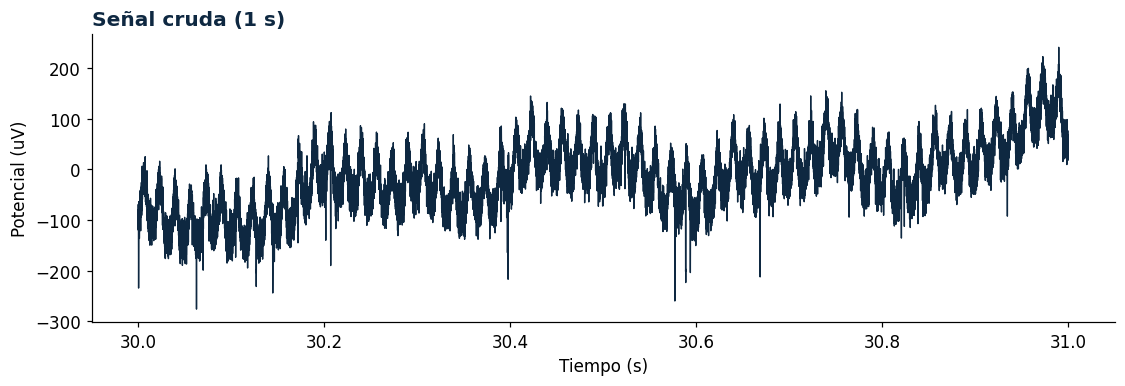

In [ ]:
def ver(x, titulo, t0, t1, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES

    m = (t >= t0) & (t < t1)  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                          # no olvides las unidades
    plt.ylabel("Potencial (uV)")


ver(cruda, "Señal cruda (1 s)", t0=30.0, t1=31.0)



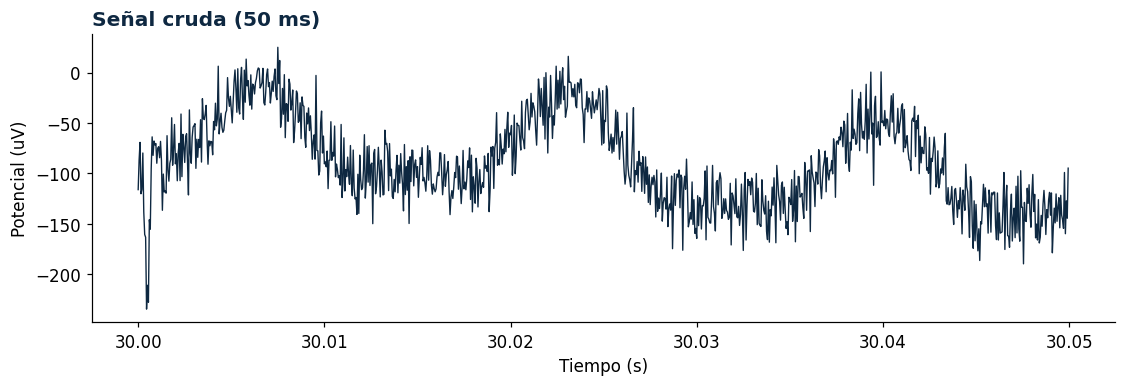

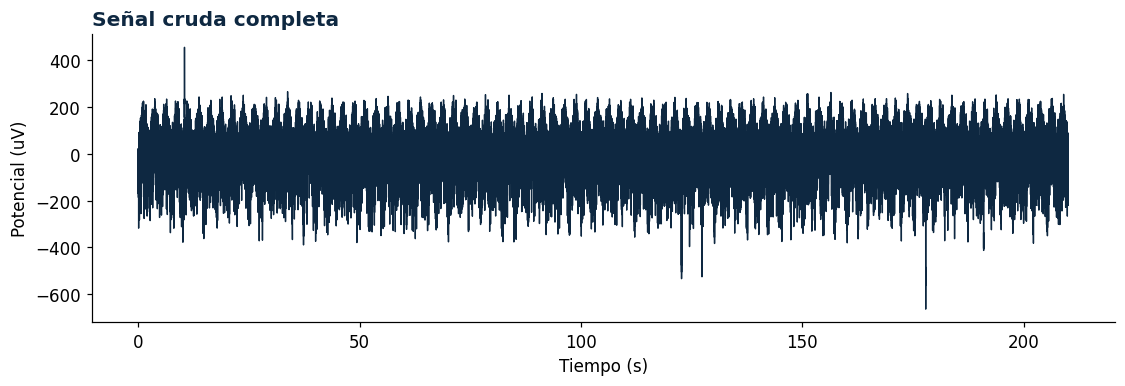

In [ ]:
# Su código aquí: los otros dos zooms (50 ms y el registro completo).

ver(cruda, "Señal cruda (50 ms)", t0=30.0, t1=30.05)
ver(cruda, "Señal cruda completa", t0=0, t1=210)

**Los tres problemas que encontramos:**
**R/**
1. La señal completa está demasiado saturada, por lo que se vuelve poco sensible a la detección de potenciales de acción; por lo que no se pueden identificar correctamente. Además, la señal llega hasta -400 uV, que no son potenciales de acción, si no que seguramente es causado por movimientos del equipo o del animal.

2. El espacio de cincuenta milisegundos dentro de ese mismo segundo es demasiado corto como para poder identificar una variación significativa de voltaje que indique un potencial de acción. Ruido de red eléctrica.

3. En la señal cruda de 1 segundo se observa una tendencia de aumento del voltaje. En dado caso, si el voltaje sigue aumentando, llegará un punto en el que los potenciales de acción no crucen el umbral definido. El tipo de ruido es deriva lenta, causada por la humedad.

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos
en la Sesión 3?

**R/** Los disparos no se pueden contar a ojo en la señal completa debido a la gran cantidad de datos.



---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_

Chat, en lenguaje de python necesito definir una funcion espectro (),  con la que necesito buscar un pico angosto en una frecuencia exacta: algo instrumental como la red eléctrica,  energía en las frecuencias muy bajas** (< 5 Hz): la deriva lenta, energía entre **300 y 3000 Hz: los potenciales de acción,  un **piso plano** que nunca baja: ruido térmico, presente en todas las frecuencias.  El tipo de datos tiene como entradas un array de voltaje, un titulo, un frecuencia maxima mostrada = 500 y una frecuencia de muestreo fs. Además la salida incluye dos arrays: Uno para las frecuencias en Hz y otro para la potencia en cada frecuencia. Utiliza scipy.signal.welch y nperseg=8192; graficar solo hasta fmax, con el eje y en escala logarítmica (plt.semilogy), ejes rotulados con unidades.


>

Pico dominante entre 40 y 200 Hz: 61.0 Hz


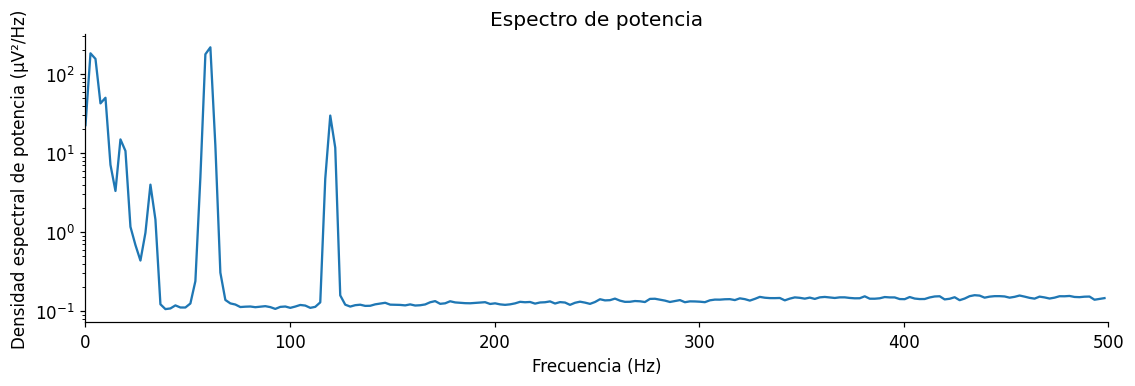

In [ ]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
from scipy.signal import welch
import matplotlib.pyplot as plt

def espectro(x, titulo, fs, fmax=500):
    """
    Calcula y grafica el espectro de potencia de una señal usando Welch.

    Parámetros:
    x      : array con el voltaje en µV
    titulo : título de la gráfica
    fs     : frecuencia de muestreo en Hz
    fmax   : frecuencia máxima que se mostrará en la gráfica (Hz)

    Retorna:
    f      : array de frecuencias en Hz
    potencia : densidad espectral de potencia en µV²/Hz
    """

    # Calcular el espectro mediante el método de Welch
    f, potencia = welch(x, fs=fs, nperseg=8192)

    # Seleccionar únicamente las frecuencias hasta fmax
    m = f <= fmax

    # Crear la gráfica
    plt.figure()

    # Graficar con el eje Y en escala logarítmica
    plt.semilogy(f[m], potencia[m])

    # Título y ejes con unidades
    plt.title(titulo)
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Densidad espectral de potencia (µV²/Hz)")

    # Mostrar únicamente hasta fmax
    plt.xlim(0, fmax)

    # Devolver los dos arrays
    return f, potencia


# Al final tienen que quedar definidas estas dos variables:


f, P = espectro(cruda,"Espectro de potencia",fs, 500)      # llamen a su función aquí

# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

In [ ]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.



In [ ]:
# El pico no cae exactamente en 60,0 Hz. Miren cuánto vale f[1] - f[0]: esa es la resolución de su espectro. ¿Explica la diferencia?

Dif = f[1]-f[0]
print(Dif)
# R/La resolusión del espectro es de 2.44 HZ. El  pico cae en 61.0 Hz. La resolución explica esto debido a que hay un margen de error de 2.44.

# Hay otro pico más pequeño, al doble de 60 Hz. ¿Cómo se llama y de dónde sale?

# R/Es un armónico de la red electrica (60Hz), aparece porque la red eléctrica tiene una oscilación regular entre 60/120/180 Hz.

# La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro?

# R/Si aparece como un pico en el espectro, al inicio de la curva.

#Miren cuánto dura un segmento de Welch (nperseg / fs, en segundos) y compárenlo con el período de la deriva (1/0,4 Hz = 2,5 s).
#¿Cabe siquiera un ciclo dentro del segmento? Repitan el espectro con nperseg = 200000 y miren qué aparece por debajo de 1 Hz.


#¿Qué se dañó a cambio?








2.44140625


## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt:_
>Estoy trabajando en el procesamiento de señales neuronales, utilizando Python como lenguaje. Quiero realizar un filtro de frecuencias para obtener señales limpias. Para ello requiero: una función filtrar() que reciba como entradas un array de la señal, una frecuencia de muestreo, los puntos de corte de mi filtro de frecuencias (alta y baja) y un orden = 3. Mi salida debe ser la señal ya filtrada, de la misma longitud de x. El filtro debe ser tipo Butterworth; si solo se da alta, es pasa-bajos; si solo se da baja, es pasa-altos; si se dan las dos, pasa-banda. Además, debe incluir una fase cero (filtfilt o sosfiltfilt) y frecuencias normalizadas por Nyquist. Antes de darme el código, explícame cuál es la diferencia entre filtfilt o sosfiltfilt y por qué se me recomienda usar un output = sos en esta parte.

<Figure size 1320x374 with 0 Axes>

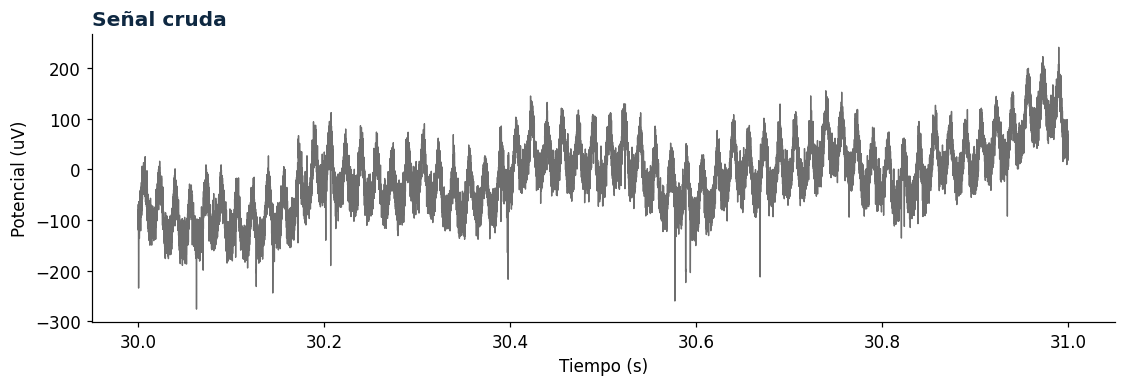

<Figure size 1320x374 with 0 Axes>

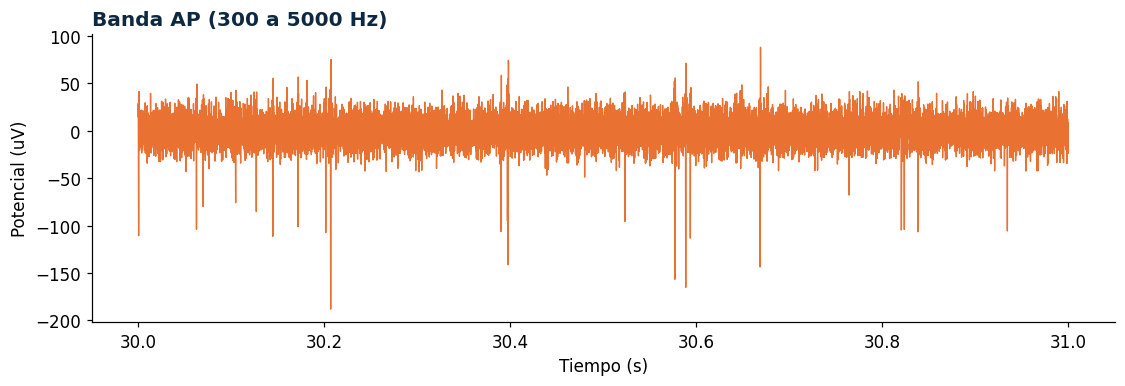

In [ ]:
from scipy.signal import butter, sosfiltfilt


def filtrar(x, fs, baja=None, alta=None, orden=3):
    """
    Filtra una señal utilizando un filtro Butterworth de fase cero.

    Parámetros
    ----------
    x : array_like
        Señal de entrada.
    fs : float
        Frecuencia de muestreo en Hz.
    baja : float, opcional
        Frecuencia de corte inferior en Hz.
        Si solo se especifica, se aplica un pasa-altos.
    alta : float, opcional
        Frecuencia de corte superior en Hz.
        Si solo se especifica, se aplica un pasa-bajos.
    orden : int, opcional
        Orden del filtro Butterworth. Por defecto: 3.

    Retorna
    -------
    y : ndarray
        Señal filtrada, de la misma longitud que x.
    """

    # Convertir la señal a array
    x = np.asarray(x)

    # Comprobaciones básicas
    if fs <= 0:
        raise ValueError("La frecuencia de muestreo 'fs' debe ser positiva.")

    if orden < 1:
        raise ValueError("El orden del filtro debe ser >= 1.")

    if baja is None and alta is None:
        raise ValueError("Debes especificar 'baja', 'alta' o ambas.")

    # Frecuencia de Nyquist
    nyquist = fs / 2

    # Determinar tipo de filtro y normalizar frecuencias
    if baja is not None and alta is not None:
        # Pasa-banda
        if baja <= 0 or alta <= 0:
            raise ValueError("Las frecuencias de corte deben ser positivas.")

        if baja >= alta:
            raise ValueError("'baja' debe ser menor que 'alta'.")

        if alta >= nyquist:
            raise ValueError(
                "La frecuencia 'alta' debe ser menor que la frecuencia de Nyquist."
            )

        frecuencias = [baja / nyquist, alta / nyquist]
        tipo = "bandpass"

    elif alta is not None:
        # Pasa-bajos
        if alta <= 0 or alta >= nyquist:
            raise ValueError(
                "'alta' debe estar entre 0 y la frecuencia de Nyquist."
            )

        frecuencias = alta / nyquist
        tipo = "lowpass"

    else:
        # Pasa-altos
        if baja <= 0 or baja >= nyquist:
            raise ValueError(
                "'baja' debe estar entre 0 y la frecuencia de Nyquist."
            )

        frecuencias = baja / nyquist
        tipo = "highpass"

    # Diseñar filtro Butterworth usando Secciones de Segundo Orden (SOS)
    sos = butter(
        orden,
        frecuencias,
        btype=tipo,
        output="sos"
    )

    # Filtrado hacia adelante y hacia atrás -> fase cero
    y = sosfiltfilt(sos, x)

    return y
AP = filtrar(cruda, fs, baja=300, alta=5000)       # pasa-banda de 300 a 5000 Hz sobre la señal cruda

plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_ En este caso, el pasa-banda se encarga de eliminar el ruido de 60Hz al establecer límites de frecuencias entre 300-5000 Hz para interpretar señales como potencial de acción, eliminando las frecuencias del ruido de red sin necesidad de notch.
La deriva desaparece junto con la una buena parte de los artefactos y se normaliza la señal.
Un notch haría falta si las frecuencias de los potenciales de acción se sobrelapan con las frecuencias del ruido de la red o de artefactos.

### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

El codigo inicial estaba mal porque al definir LFP se usó baja=300, y en la función filtrar ese argumento indica un filtro pasa-altos, es decir, conserva las frecuencias mayores a 300 Hz. Sin embargo, la banda LFP corresponde a frecuencias menores de 300 Hz, por lo que debía usarse alta=300. Además, el filtrado debía aplicarse sobre sin_red, que ya tenía eliminados los componentes de 60 y 120 Hz.



Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

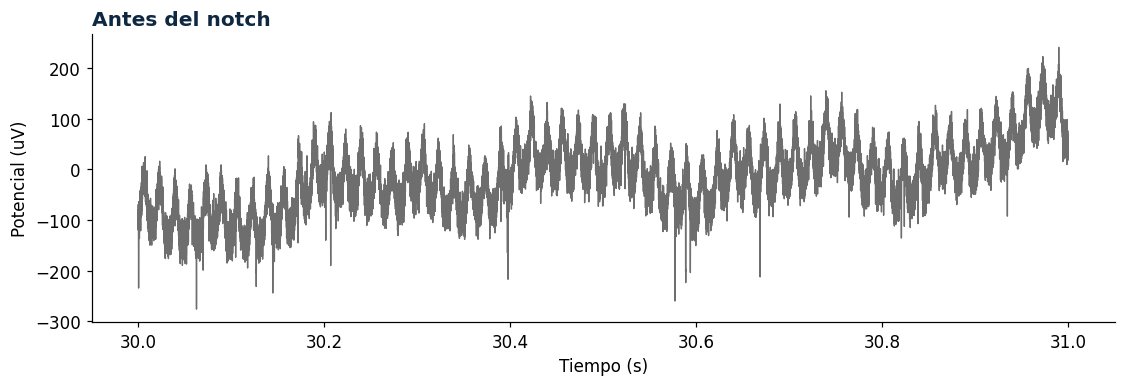

<Figure size 1320x374 with 0 Axes>

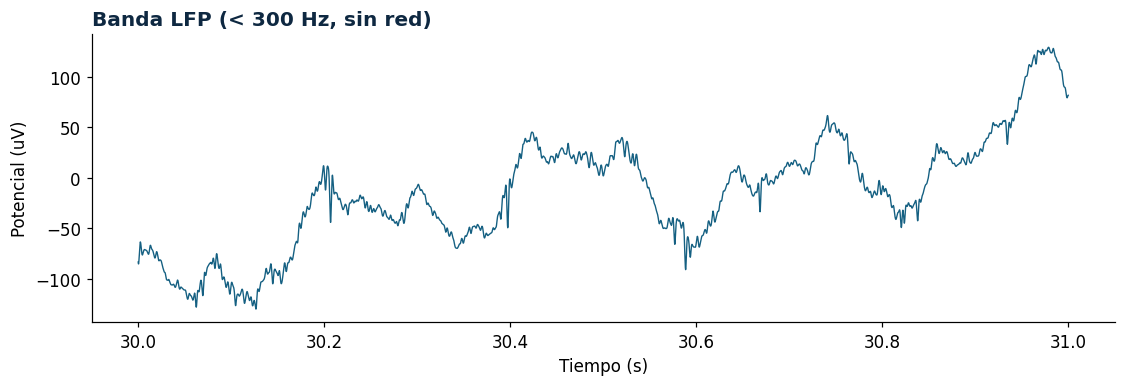

In [ ]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.
import numpy as np
from scipy.signal import iirnotch, filtfilt


def notch(x, f0, fs, Q=30):
    """
    Aplica un filtro notch IIR a una señal.

    Parámetros
    ----------
    x : array_like
        Señal de entrada, en µV.
    f0 : float
        Frecuencia central del notch, en Hz.
    fs : float
        Frecuencia de muestreo, en Hz.
    Q : float, opcional
        Factor de calidad del filtro. Por defecto: 30.

    Retorna
    -------
    y : ndarray
        Señal filtrada, en µV.
    """

    # Diseñar el filtro notch.
    # f0 está en Hz y fs está en Hz.
    b, a = iirnotch(w0=f0, Q=Q, fs=fs)

    # Aplicar el filtro hacia adelante y hacia atrás.
    # filtfilt no cambia las unidades: µV -> µV.
    y = filtfilt(b, a, x)

    return y


cruda_60 = notch(cruda, f0=60, fs=fs, Q=30)
sin_red = notch(cruda_60, f0=120, fs=fs, Q=30)

LFP = filtrar(sin_red, fs, alta=300)

plt.figure()
ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)

plt.figure()
ver(LFP, "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)


In [ ]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_
1. Al aplicar el notch en 9 Hz se observa que los picos principales se "abren" en dos picos más pequeños cada uno.
2. Al graficar el espectro de potencia con un Q=2 se observa una disminución en la nitidez o agudeza de los picos de altas frecuencias. Para observar los cambios toca acercar la gráfica a un tiempo muy pequeño (en este caso, 1 ms).
3. Al filtrar por 100 Hz se cuela el ruido de la red. Como se filtra por debajo de 800 Hz, se pierden algunos disparos y el registro de potencial de toda la señal disminuye significativamente.
Es importante hacer el diagnóstico antes que el filtrado para saber cuál es la banda de frecuencias ideal a mantener y evitar perder información importante

<Figure size 1320x374 with 0 Axes>

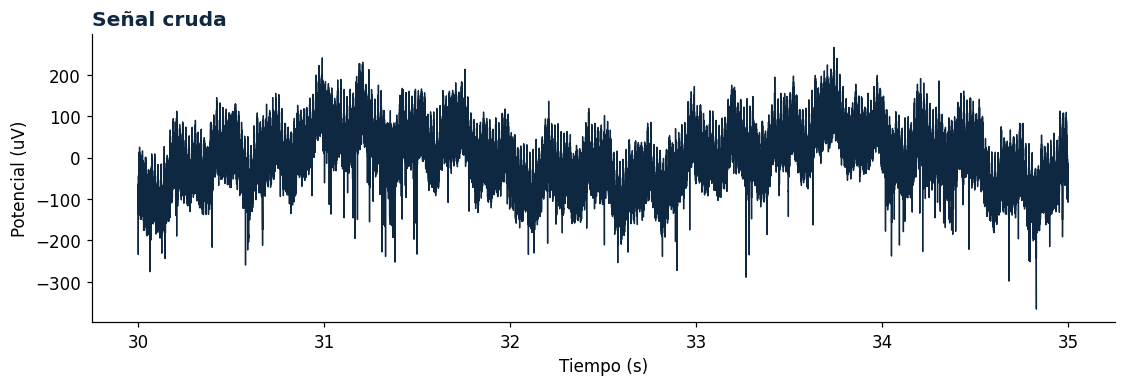

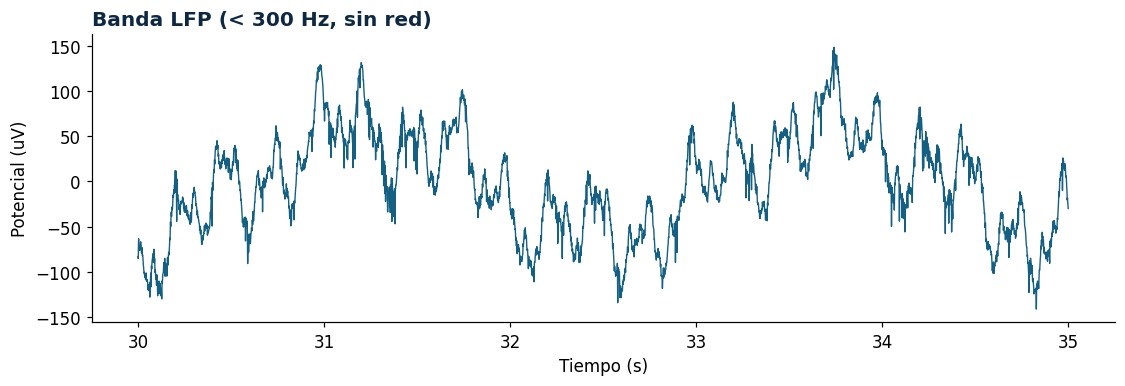

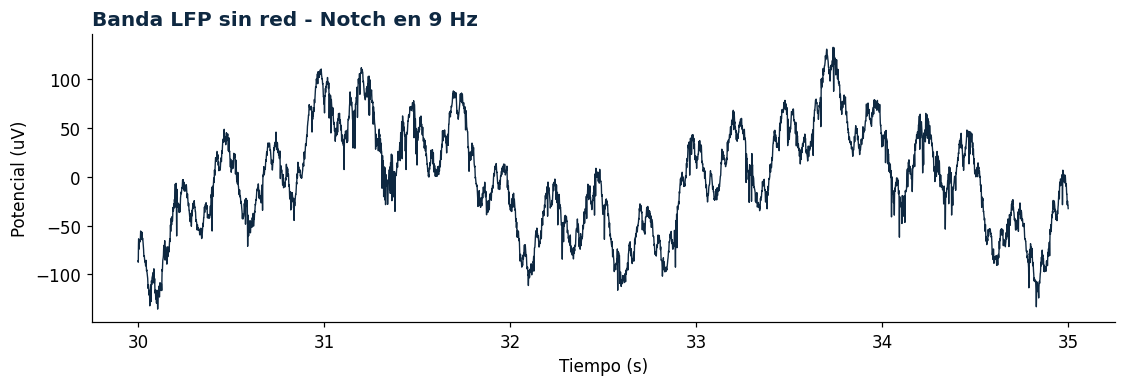

<Figure size 1320x374 with 0 Axes>

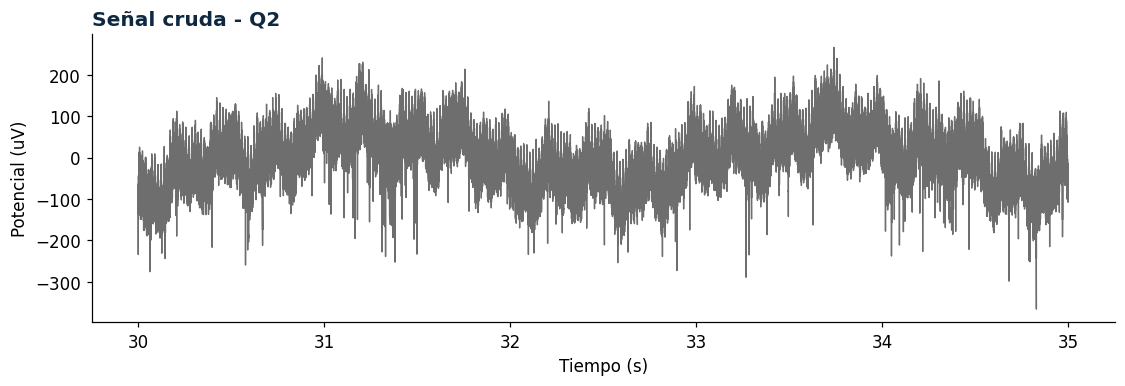

<Figure size 1320x374 with 0 Axes>

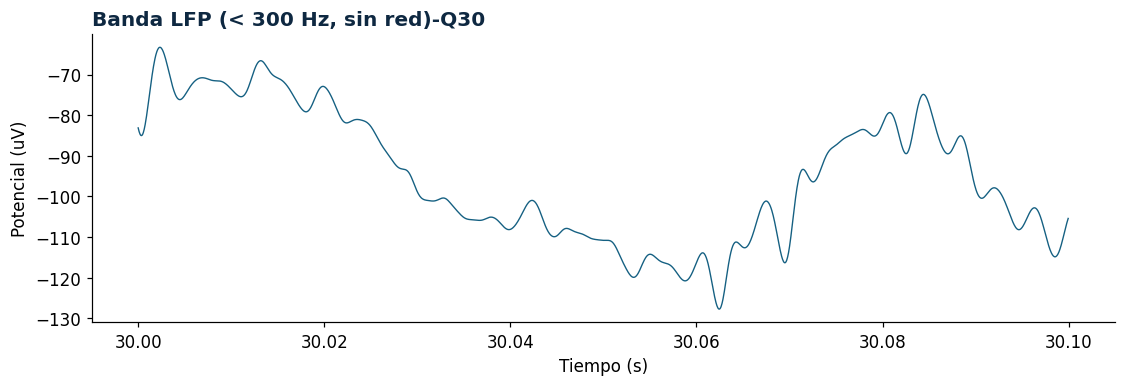

<Figure size 1320x374 with 0 Axes>

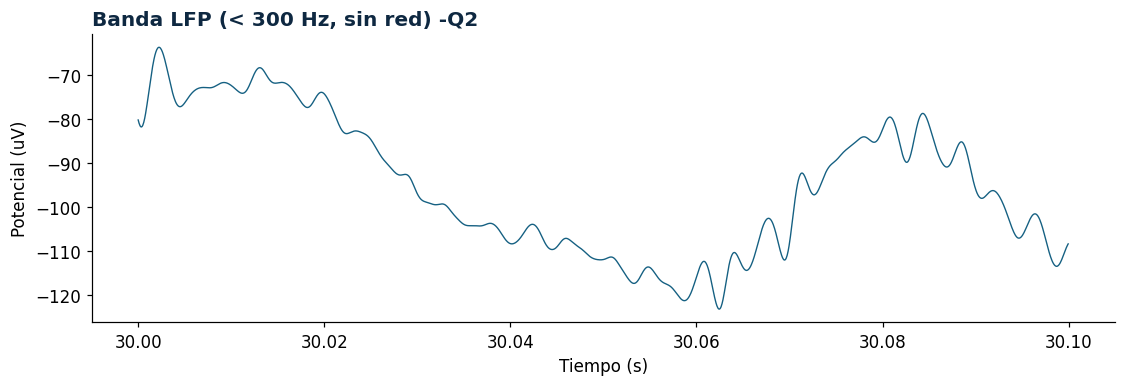

<Figure size 1320x374 with 0 Axes>

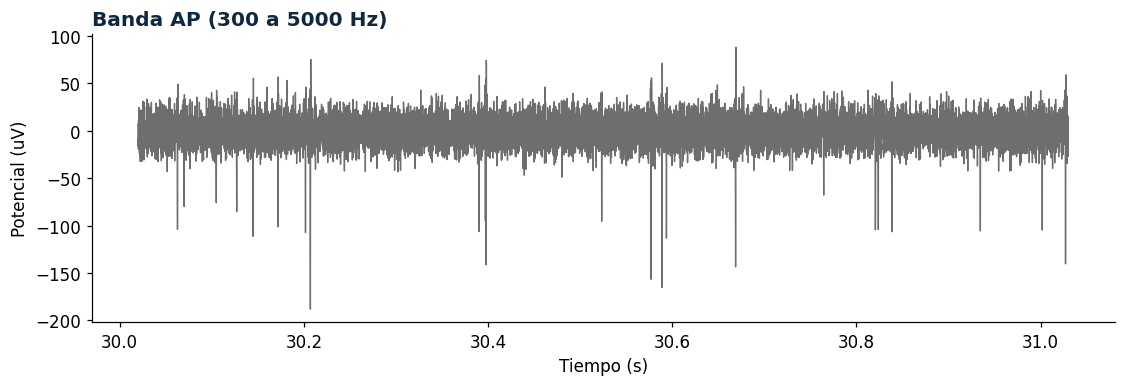

<Figure size 1320x374 with 0 Axes>

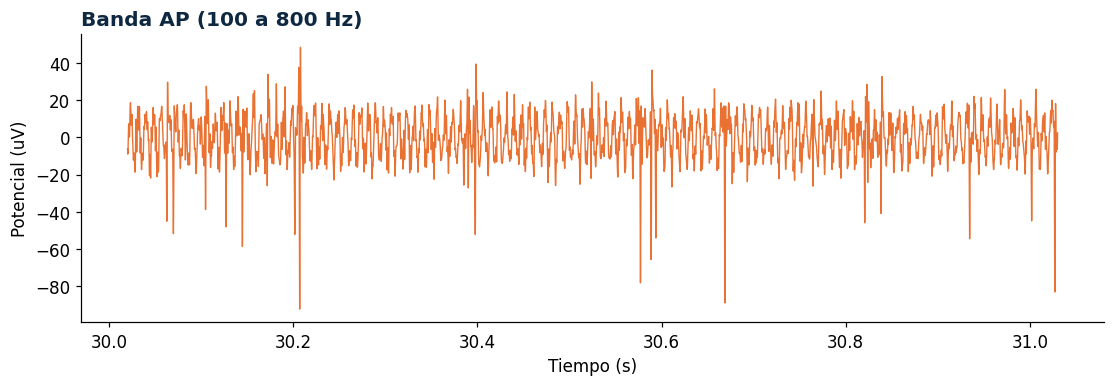

In [ ]:
notch_9 = notch(sin_red, f0=9, fs=fs, Q=30)
plt.figure()

filt= filtrar(notch_9, fs, alta=300)

ver(cruda, "Señal cruda", t0=30.0, t1=35.0)

ver(LFP, "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=35.0, color=TEAL)

ver(filt, "Banda LFP sin red - Notch en 9 Hz", t0=30.0, t1=35.0)


cruda_60_2 = notch(cruda, f0=60, fs=fs, Q=2)
sin_red2 = notch(cruda_60_2, f0=120, fs=fs, Q=2)
LFP2 = filtrar(sin_red2, fs, alta=300)

plt.figure()
ver(cruda, "Señal cruda - Q2", t0=30.0, t1=35.0, color=GRAY)
plt.figure()
ver(LFP, "Banda LFP (< 300 Hz, sin red)-Q30", t0=30.0, t1=30.1, color=TEAL)
plt.figure()
ver(LFP2, "Banda LFP (< 300 Hz, sin red) -Q2", t0=30.0, t1=30.1, color=TEAL)

AP2 = filtrar(cruda, fs, baja=100, alta=800)       # pasa-banda de 100 a 800 Hz sobre la señal cruda

plt.figure()
ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.02, t1=31.03, color=GRAY)
plt.figure()
ver(AP2, "Banda AP (100 a 800 Hz)", t0=30.02, t1=31.03, color=ORANGE)


---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [ ]:
import numpy as np

def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """
    Detecta potenciales de acción extracelulares en una señal filtrada.

    Parámetros
    ----------
    x : array_like
        Señal filtrada en microvoltios (µV), muestreada a fs Hz.
    fs : float
        Frecuencia de muestreo en Hz.
    k : float, opcional
        Número de desviaciones robustas para el umbral (default 4.5).
    muerto_ms : float, opcional
        Periodo refractario en milisegundos (default 1.5 ms).

    Devuelve
    --------
    np.ndarray
        Índices enteros (muestras) de los picos mínimos de cada spike,
        ordenados y sin repetir.
    """
    # Conversión de entradas
    x = np.asarray(x, dtype=float)          # señal en µV
    fs = float(fs)                          # frecuencia de muestreo en Hz
    muerto_ms = float(muerto_ms)            # periodo muerto en ms

    # Validaciones básicas
    if x.ndim != 1:
        raise ValueError("x debe ser un vector unidimensional")
    if fs <= 0:
        raise ValueError("fs debe ser > 0")
    if muerto_ms < 0:
        raise ValueError("muerto_ms debe ser >= 0")
    if np.any(np.isnan(x)):
        raise ValueError("x contiene NaN")

    # ------------------------------------------------------------
    # 1. Estimación robusta del ruido
    # ------------------------------------------------------------
    # Se usa exactamente la misma definición que en el código externo:
    # sigma = median(|x|) / 0.6745
    # Esta fórmula asume que la señal ya está centrada en 0 µV
    # (típico tras un filtrado paso-alto).
    sigma = np.median(np.abs(x)) / 0.6745   # desviación estándar robusta, µV

    # Umbral para deflexiones negativas:
    # k desviaciones estándar por debajo de 0 µV.
    umbral = -k * sigma                     # umbral, µV

    # ------------------------------------------------------------
    # 2. Muestras por debajo del umbral
    # ------------------------------------------------------------
    por_debajo = x < umbral                 # máscara booleana
    idx_debajo = np.flatnonzero(por_debajo) # índices de esas muestras

    # Si no hay ninguna muestra bajo el umbral, no hay spikes.
    if idx_debajo.size == 0:
        return np.array([], dtype=int)

    # ------------------------------------------------------------
    # 3. Agrupar muestras contiguas por debajo del umbral
    # ------------------------------------------------------------
    saltos = np.where(np.diff(idx_debajo) > 1)[0]

    inicios = np.concatenate(([0], saltos + 1))
    finales = np.concatenate((saltos, [idx_debajo.size - 1]))

    picos_candidatos = []
    for ini, fin in zip(inicios, finales):
        segmento = idx_debajo[ini:fin + 1]      # muestras contiguas del evento
        pos_min_local = np.argmin(x[segmento])  # posición del mínimo dentro del segmento
        picos_candidatos.append(segmento[pos_min_local])

    picos_candidatos = np.array(picos_candidatos, dtype=int)

    # ------------------------------------------------------------
    # 4. Periodo muerto / refractario
    # ------------------------------------------------------------
    # Convertir ms a muestras:
    # muerto_ms [ms] × fs [muestras/s] / 1000 [ms/s] = muestras
    muerto_muestras = int(round(muerto_ms * fs / 1000.0))
    if muerto_muestras < 1:
        muerto_muestras = 1                  # al menos una muestra

    spikes = []
    ultimo_spike = -np.inf                   # índice del último spike aceptado

    for pico in picos_candidatos:
        if pico - ultimo_spike > muerto_muestras:
            spikes.append(pico)
            ultimo_spike = pico

    return np.array(spikes, dtype=int)

indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5458 disparos en 210 s (26.0 por segundo)


In [ ]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

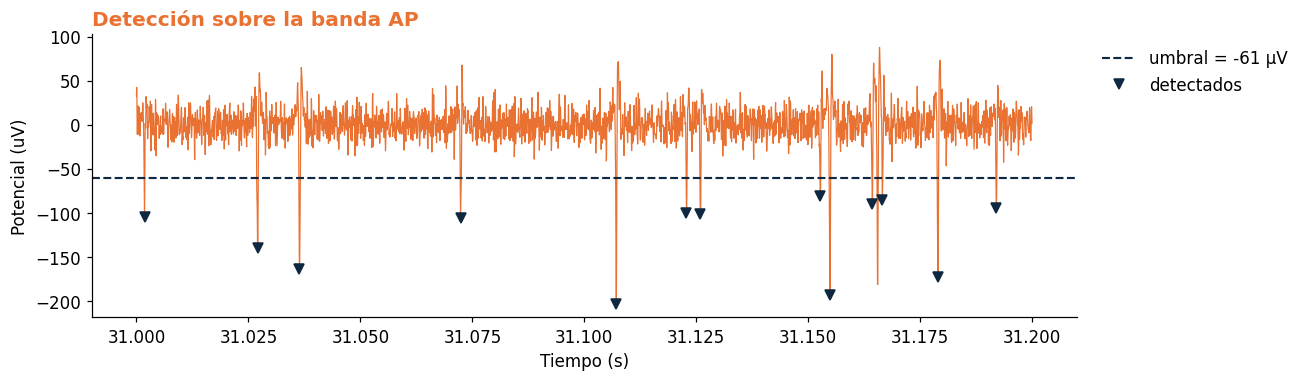

In [ ]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(t[d], AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")  # ¿tiempo y voltaje de qué?
plt.xlabel("Tiempo (s)"); plt.ylabel("Potencial (uV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_

>Estoy trabajando en Python con datos de un registro extracelular eléctrico organizado en un array. Tengo un detector "indices" con los índices del array que se consideran spikes. Debo buscar los verdaderos positivos (VP), falsos positivos (FP) y falsos negativos (FN) de los spikes detectados. Escribe una funcion emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN).
Reglas: 1. Mi detector devuelve el instante del mínimo, por lo que fijaremos una ventana de tolerancia de 1 ms dentro de la cual dos marcas cuentan como la misma. 2. Cada disparo real puede emparejarse con una sola detección, para evitar contar dos detecciones sobre el mismo evento como aciertos.

In [ ]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()     # los tiempos reales, en segundos

# Su código aquí: la función emparejar(), y con ella los tres números.

def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """
    Empareja detecciones con disparos reales dentro de una tolerancia temporal.

    Parámetros
    ----------
    detectados_s : array_like
        Tiempos (en segundos) donde el detector marcó un spike.
    reales_s : array_like
        Tiempos (en segundos) de los spikes reales/ground truth.
    tol_ms : float, opcional
        Tolerancia en milisegundos. Dos marcas cuentan como la misma
        si |t_det - t_real| <= tol_ms.

    Devuelve
    --------
    (VP, FP, FN) : tuple[int, int, int]
        VP : verdaderos positivos (detecciones emparejadas con un real)
        FP : falsos positivos     (detecciones sin real correspondiente)
        FN : falsos negativos     (reales sin detección correspondiente)
    """
    # Convertir a arrays NumPy 1-D y ordenar cronológicamente.
    det = np.sort(np.asarray(detectados_s, dtype=float).ravel())
    real = np.sort(np.asarray(reales_s, dtype=float).ravel())

    # Convertir la tolerancia de ms a segundos.
    tol_s = tol_ms / 1000.0

    i_real = 0      # puntero sobre los reales
    vp = 0          # contador de emparejamientos

    # Recorrer las detecciones en orden temporal.
    for t_det in det:
        # Descartar reales que ya son demasiado tempranos para esta detección.
        # Como las detecciones van en orden creciente, esos reales
        # no podrán emparejarse con ninguna detección futura.
        while i_real < len(real) and real[i_real] < t_det - tol_s:
            i_real += 1

        # Si el real actual cae dentro de la ventana de tolerancia,
        # se empareja con esta detección.
        if i_real < len(real) and real[i_real] <= t_det + tol_s:
            vp += 1
            i_real += 1   # cada real se usa una sola vez

    fp = len(det) - vp
    fn = len(real) - vp

    return int(vp), int(fp), int(fn)
VP, FP, FN = emparejar(tiempos, reales)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5454   FP = 4   FN = 169
precisión     = 0.999
exhaustividad = 0.970


In [ ]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5458 spikes
  En realidad hay    5623
  Aciertos           5454   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.0%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?

**R/** Elegiriamos un valor de k un poco más bajo (k = 4.25) teniendo en cuenta la media armónica obtenida en las gráficas. Consideramos que es un punto de balance ideal entre comprometer precisión y exhaustividad. Para muestreos con un ratio señal/ruido alto, se preferiría un valor K un poco más alto, porque no comprometería significativamente el número de FN. En caso contrario, un K más bajo es más permisivo para la detección de spikes difíciles de encontrar por exceso de ruido

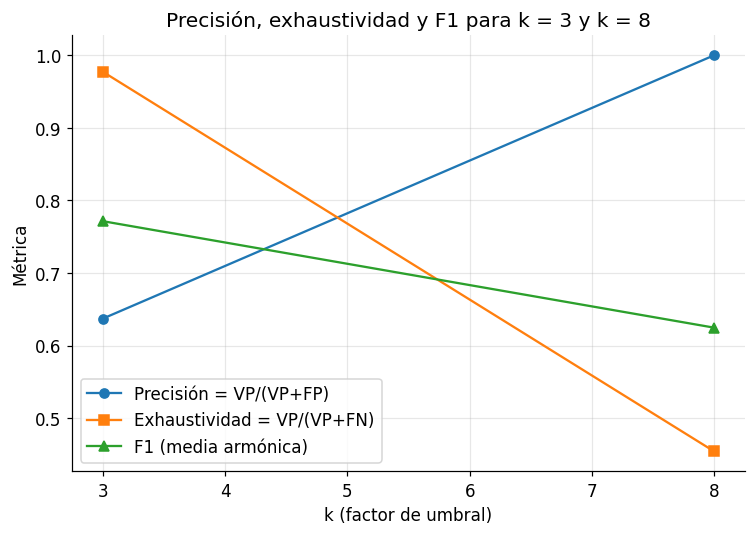

In [ ]:
# ------------------------------------------------------------
# 1. Detección con k = 3 y k = 8
# ------------------------------------------------------------
spikes_k3 = detectar_spikes(AP, fs, k=3, muerto_ms=1.5)
spikes_k8 = detectar_spikes(AP, fs, k=8, muerto_ms=1.5)

# Convertir índices a segundos
detectados_k3_s = spikes_k3 / fs
detectados_k8_s = spikes_k8 / fs

# Emparejar con los reales
VP3, FP3, FN3 = emparejar(detectados_k3_s, reales, tol_ms=1.0)
VP8, FP8, FN8 = emparejar(detectados_k8_s, reales, tol_ms=1.0)

# ------------------------------------------------------------
# 2. Métricas para k = 3
# ------------------------------------------------------------
if VP3 + FP3 > 0:
    prec3 = VP3 / (VP3 + FP3)
else:
    prec3 = 0.0

if VP3 + FN3 > 0:
    rec3 = VP3 / (VP3 + FN3)
else:
    rec3 = 0.0

f1_3 = (2 * prec3 * rec3 / (prec3 + rec3)) if (prec3 + rec3) > 0 else 0.0

# ------------------------------------------------------------
# 3. Métricas para k = 8
# ------------------------------------------------------------
if VP8 + FP8 > 0:
    prec8 = VP8 / (VP8 + FP8)
else:
    prec8 = 0.0

if VP8 + FN8 > 0:
    rec8 = VP8 / (VP8 + FN8)
else:
    rec8 = 0.0

f1_8 = (2 * prec8 * rec8 / (prec8 + rec8)) if (prec8 + rec8) > 0 else 0.0

# ------------------------------------------------------------
# 4. Gráfica
# ------------------------------------------------------------
ks = [3, 8]
precisiones = [prec3, prec8]
exhaustividades = [rec3, rec8]
f1s = [f1_3, f1_8]

plt.figure(figsize=(7, 5))
plt.plot(ks, precisiones, marker='o', label='Precisión = VP/(VP+FP)')
plt.plot(ks, exhaustividades, marker='s', label='Exhaustividad = VP/(VP+FN)')
plt.plot(ks, f1s, marker='^', label='F1 (media armónica)')

plt.xlabel('k (factor de umbral)')
plt.ylabel('Métrica')
plt.title('Precisión, exhaustividad y F1 para k = 3 y k = 8')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

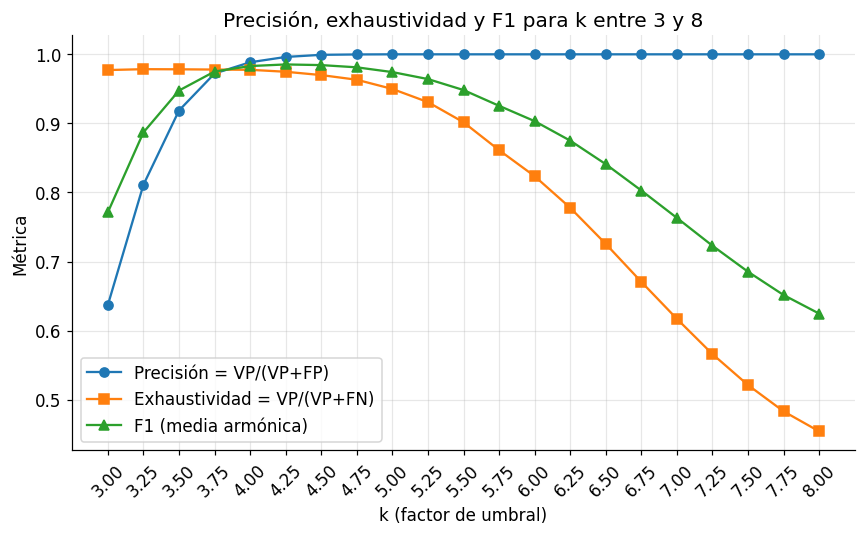

In [ ]:
# Repetimos con un vector de k entre 3 y 8 con paso fijo de 0.25 (creo que esto es lo que querías profe... pero te dejé el grafico anterior por si acaso)
ks = np.arange(3.0, 8.01, 0.25)   # 21 puntos: 3.00, 3.25, ..., 8.00

# Listas donde guardaremos las métricas para cada k
precisiones = []
exhaustividades = []
f1s = []

# ------------------------------------------------------------
# 1. Bucle principal sobre los valores de k
# ------------------------------------------------------------
for k in ks:
    # 1.1 Detectar spikes con el umbral correspondiente a este k
    indices = detectar_spikes(AP, fs, k=k, muerto_ms=1.5)

    # 1.2 Convertir índices de muestras a tiempos en segundos
    tiempos_det = indices / fs

    # 1.3 Emparejar detecciones con spikes reales usando tolerancia de 1 ms
    VP, FP, FN = emparejar(tiempos_det, reales, tol_ms=1.0)

    # 1.4 Calcular precisión y exhaustividad (evitando división por cero)
    prec = VP / (VP + FP) if (VP + FP) > 0 else 0.0
    rec  = VP / (VP + FN) if (VP + FN) > 0 else 0.0

    # 1.5 Calcular F1 (media armónica) evitando división por cero
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0

    # 1.6 Guardar métricas en las listas
    precisiones.append(prec)
    exhaustividades.append(rec)
    f1s.append(f1)

# ------------------------------------------------------------
# 2. Gráfica de las tres curvas
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(ks, precisiones, marker='o', label='Precisión = VP/(VP+FP)')
plt.plot(ks, exhaustividades, marker='s', label='Exhaustividad = VP/(VP+FN)')
plt.plot(ks, f1s, marker='^', label='F1 (media armónica)')

plt.xlabel('k (factor de umbral)')
plt.ylabel('Métrica')
plt.title('Precisión, exhaustividad y F1 para k entre 3 y 8')
plt.grid(True, alpha=0.3)
plt.xticks(ks, rotation=45)   # mostrar todos los valores de k
plt.legend()
plt.tight_layout()
plt.show()

### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

In [ ]:
import numpy as np

# Supón que existen:
# AP          -> señal filtrada (µV)
# fs          -> frecuencia de muestreo (Hz)
# reales_s    -> tiempos reales de spikes (s), ordenados

muerto_ms_original = 1.5

# Convertir muerto_ms a segundos
muerto_s = muerto_ms_original / 1000.0   # s

# Calcular intervalos entre spikes reales consecutivos
intervalos = np.diff(reales)           # s

# Contar cuántos intervalos son más cortos que el período muerto
# (esos segundos spikes caen dentro del muerto del anterior y no pueden
#  ser detectados como eventos separados por el detector)
n_dentro_muerto = np.sum(intervalos < muerto_s)

# Detectar con el período muerto original
indices_det = detectar_spikes(AP, fs, k=4.5, muerto_ms=muerto_ms_original)
tiempos_det = indices_det / fs

# Emparejar para obtener FN
VP, FP, FN = emparejar(tiempos_det, reales, tol_ms=1.0)

print(f"muerto_ms = {muerto_ms_original} ms")
print(f"Intervalos entre reales menores que {muerto_ms_original} ms: {n_dentro_muerto}")
print(f"FN del detector con muerto_ms={muerto_ms_original}: {FN}")
print(f"Diferencia FN - n_dentro_muerto: {FN - n_dentro_muerto}")

muerto_ms_nuevo = 0.4

# Detectar con el nuevo período muerto
indices_det_nuevo = detectar_spikes(AP, fs, k=4.5, muerto_ms=muerto_ms_nuevo)
tiempos_det_nuevo = indices_det_nuevo / fs

# Emparejar
VP_nuevo, FP_nuevo, FN_nuevo = emparejar(tiempos_det_nuevo, reales, tol_ms=1.0)

# Métricas
prec_nueva = VP_nuevo / (VP_nuevo + FP_nuevo) if (VP_nuevo + FP_nuevo) > 0 else 0.0
rec_nueva  = VP_nuevo / (VP_nuevo + FN_nuevo) if (VP_nuevo + FN_nuevo) > 0 else 0.0
f1_nueva   = (2 * prec_nueva * rec_nueva / (prec_nueva + rec_nueva)) if (prec_nueva + rec_nueva) > 0 else 0.0

print(f"\nCon muerto_ms = {muerto_ms_nuevo} ms")
print(f"VP = {VP_nuevo}, FP = {FP_nuevo}, FN = {FN_nuevo}")
print(f"Precisión   = {prec_nueva:.3f}")
print(f"Exhaustividad = {rec_nueva:.3f}")
print(f"F1          = {f1_nueva:.3f}")

muerto_ms = 1.5 ms
Intervalos entre reales menores que 1.5 ms: 122
FN del detector con muerto_ms=1.5: 169
Diferencia FN - n_dentro_muerto: 47

Con muerto_ms = 0.4 ms
VP = 5517, FP = 4, FN = 106
Precisión   = 0.999
Exhaustividad = 0.981
F1          = 0.990


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

**R/** Con el nuevo tiempo muesto ganamos exhaustividad en la medición sin comprometer su presición. La explicación que mejor se ajusta al gran número de falsos negativos es la agrupación de diferentes disparos en un mismo evento (122 de 169). Creemos que se justifica el uso de un menor tiempo muerto de al tratarse de datos de 3 neuronas diferentes (siempre y cuando estén conectadas). Nos quedamos con el periodo muerto de 0,4 ms, pues permite la reducción del número de FN sin provocar un aumento de FP. Gracias a esto, la exhaustividad del análisis aumentó sin comprometer la precisión.

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [ ]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

Ventana: 0.7 ms antes, 1.3 ms después
Muestras por ventana: 41
Todas las ventanas están dentro del arreglo.


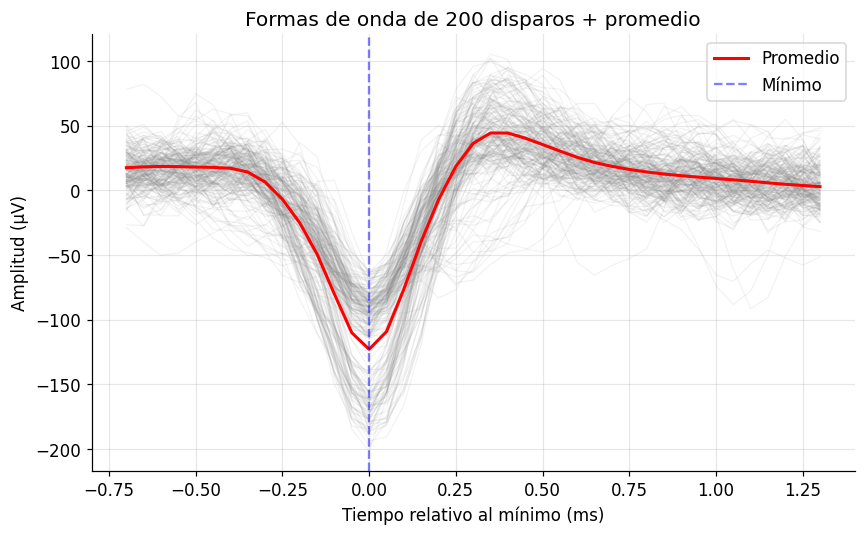

In [ ]:
# Su código aquí.
# ------------------------------------------------------------
# 1. Parámetros de la ventana temporal
# ------------------------------------------------------------
pre_ms = 0.7     # ms antes del mínimo
post_ms = 1.3    # ms después del mínimo

# Convertir de ms a número de muestras
n_pre = int(round(pre_ms * fs / 1000.0))
n_post = int(round(post_ms * fs / 1000.0))
n_total = n_pre + n_post + 1      # longitud total de la ventana en muestras

print(f"Ventana: {pre_ms} ms antes, {post_ms} ms después")
print(f"Muestras por ventana: {n_total}")

# ------------------------------------------------------------
# 2. Detección de spikes
# ------------------------------------------------------------
indices = detectar_spikes(AP, fs, k=4.5, muerto_ms=1.5)

# ------------------------------------------------------------
# 3. Extracción de ventanas con control de bordes
# ------------------------------------------------------------
ventanas = []
invalidos = 0

for idx in indices:
    inicio = idx - n_pre
    fin = idx + n_post

    # Comprobar que la ventana no se salga del array
    if inicio < 0 or fin >= len(AP):
        invalidos += 1
        continue

    # Extraer la ventana como segmento de la señal filtrada
    ventana = AP[inicio:fin + 1]        # µV
    ventanas.append(ventana)

# Convertir lista a matriz (n_disparos_válidos × n_total)
ventanas = np.array(ventanas)

# Aviso al usuario si hubo ventanas descartadas
if invalidos > 0:
    print(f"⚠️ Aviso: {invalidos} disparos descartados porque su ventana "
          f"se salía del arreglo de datos.")
else:
    print("Todas las ventanas están dentro del arreglo.")

if len(ventanas) == 0:
    print("No se pudieron extraer ventanas. Revisa la señal o el detector.")
    # Terminar o evitar la gráfica
else:
    # ------------------------------------------------------------
    # 4. Eje de tiempo en ms relativo al mínimo
    # ------------------------------------------------------------
    # La muestra central (índice n_pre dentro de la ventana) corresponde
    # al instante del mínimo detectado → tiempo 0 ms.
    t_ventana_ms = (np.arange(n_total) - n_pre) / fs * 1000.0   # ms

    # ------------------------------------------------------------
    # 5. Gráfica de hasta 200 formas superpuestas + promedio
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))

    # Elegir aleatoriamente hasta 200 ventanas para no saturar la figura
    n_formas = min(200, len(ventanas))
    rng = np.random.default_rng(42)                     # semilla reproducible
    idx_plot = rng.choice(len(ventanas), size=n_formas, replace=False)
    idx_plot = np.sort(idx_plot)

    # Dibujar formas individuales con transparencia
    for i in idx_plot:
        plt.plot(t_ventana_ms, ventanas[i],
                 color='gray', alpha=0.1, linewidth=0.8)

    # Forma promedio sobre todas las ventanas válidas
    forma_promedio = ventanas.mean(axis=0)              # µV
    plt.plot(t_ventana_ms, forma_promedio,
             color='red', linewidth=2.0, label='Promedio')

    # Etiquetas y formato
    plt.xlabel('Tiempo relativo al mínimo (ms)')
    plt.ylabel('Amplitud (µV)')
    plt.title(f'Formas de onda de {n_formas} disparos + promedio')
    plt.axvline(0.0, color='blue', linestyle='--', alpha=0.5, label='Mínimo')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
# Al final debe quedar definida la matriz de formas:

formas = ventanas        # matriz n_disparos x n_muestras

# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.

In [ ]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;

- qué unidades tiene cada característica;

- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

Spikes detectados: 5458
Spikes válidos para clustering: 5451


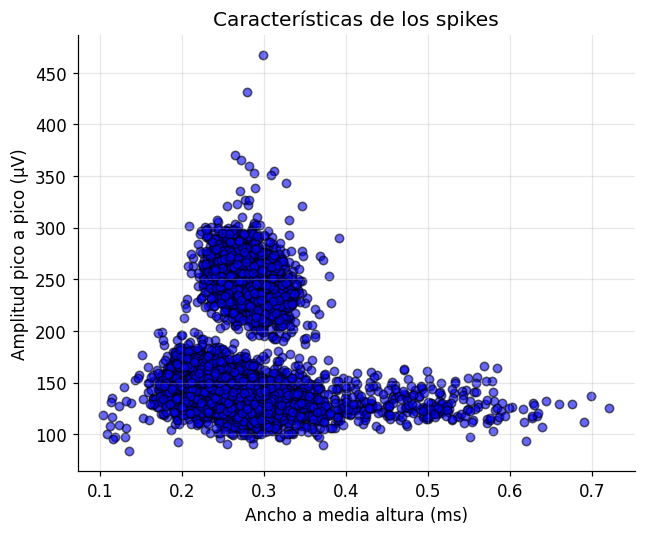

Longitud de tiempos_s: 5458
Longitud de etiquetas:  5458
Etiquetas asignadas: 5451
Etiquetas no asignadas (NaN): 7


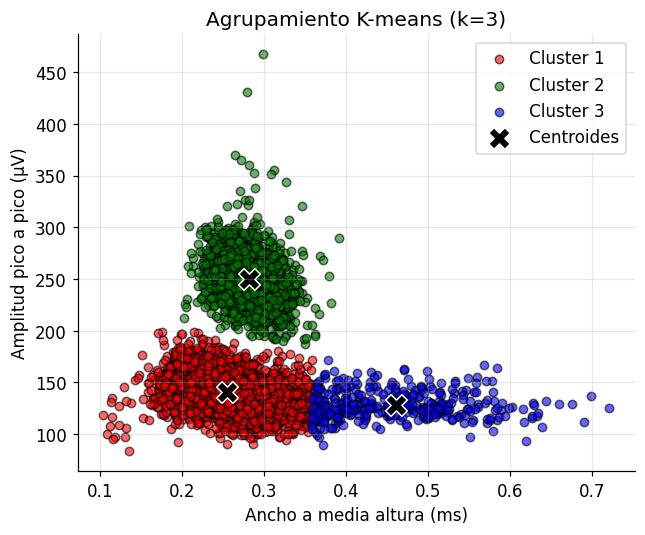

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# Supón que ya existen:
# AP          -> señal filtrada centrada en 0 (µV)
# fs          -> frecuencia de muestreo (Hz)
# detectar_spikes, emparejar ya definidas
# ============================================================

# ------------------------------------------------------------
# 1. Parámetros de la ventana
# ------------------------------------------------------------
pre_ms = 0.7
post_ms = 1.3
n_pre = int(round(pre_ms * fs / 1000.0))
n_post = int(round(post_ms * fs / 1000.0))
n_total = n_pre + n_post + 1

# Vector de tiempo relativo al mínimo (ms)
t_ventana_ms = (np.arange(n_total) - n_pre) / fs * 1000.0

# ------------------------------------------------------------
# 2. Detección de spikes
# ------------------------------------------------------------
indices = detectar_spikes(AP, fs, k=4.5, muerto_ms=1.5)
tiempos_s = indices / fs   # tiempos de TODOS los spikes detectados

# ------------------------------------------------------------
# 3. Extracción de ventanas y cálculo de características
# ------------------------------------------------------------
amplitudes_pp = []      # µV
anchos_half = []        # ms
indices_validos = []    # posiciones originales en 'indices'

for j, idx in enumerate(indices):
    inicio = idx - n_pre
    fin = idx + n_post
    if inicio < 0 or fin >= len(AP):
        continue   # descartado por borde

    ventana = AP[inicio:fin+1]

    # ---- Amplitud pico a pico ----
    amp_pp = np.max(ventana) - np.min(ventana)

    # ---- Ancho a media altura ----
    baseline = np.median(ventana[:n_pre])   # estimación de línea base
    imin_local = np.argmin(ventana)
    profundidad = baseline - ventana[imin_local]

    if profundidad <= 0:
        # No hay valle negativo claro, no se puede calcular ancho
        continue

    nivel_half = baseline - profundidad / 2.0

    # Cruce descendente antes del mínimo
    t_cruce1 = None
    for i in range(imin_local, 0, -1):
        if ventana[i-1] >= nivel_half and ventana[i] <= nivel_half:
            y0, y1 = ventana[i-1], ventana[i]
            t0, t1 = t_ventana_ms[i-1], t_ventana_ms[i]
            fracción = (nivel_half - y0) / (y1 - y0) if y1 != y0 else 0.0
            t_cruce1 = t0 + fracción * (t1 - t0)
            break

    # Cruce ascendente después del mínimo
    t_cruce2 = None
    for i in range(imin_local, n_total-1):
        if ventana[i] <= nivel_half and ventana[i+1] >= nivel_half:
            y0, y1 = ventana[i], ventana[i+1]
            t0, t1 = t_ventana_ms[i], t_ventana_ms[i+1]
            fracción = (nivel_half - y0) / (y1 - y0) if y1 != y0 else 0.0
            t_cruce2 = t0 + fracción * (t1 - t0)
            break

    if t_cruce1 is not None and t_cruce2 is not None:
        ancho_ms = t_cruce2 - t_cruce1
        # Guardar características y el índice original
        amplitudes_pp.append(amp_pp)
        anchos_half.append(ancho_ms)
        indices_validos.append(j)   # posición en 'indices' y por ende en 'tiempos_s'

# Convertir a arrays
amplitudes = np.array(amplitudes_pp)
anchos = np.array(anchos_half)
indices_validos = np.array(indices_validos)

print(f"Spikes detectados: {len(tiempos_s)}")
print(f"Spikes válidos para clustering: {len(amplitudes)}")

# ------------------------------------------------------------
# 4. Gráfico de dispersión de características
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
plt.scatter(anchos, amplitudes, c='blue', alpha=0.6, edgecolors='k', s=30)
plt.xlabel('Ancho a media altura (ms)')
plt.ylabel('Amplitud pico a pico (µV)')
plt.title('Características de los spikes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. K-means
# ------------------------------------------------------------
X = np.column_stack([anchos, amplitudes])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
etiquetas_clustering = kmeans.fit_predict(X_scaled)

# ------------------------------------------------------------
# 6. Crear vector 'etiquetas' alineado con 'tiempos_s'
# ------------------------------------------------------------
# Inicializar con NaN para todos los spikes detectados
etiquetas = np.full(len(tiempos_s), np.nan)

# Asignar las etiquetas del clustering solo a los índices válidos
etiquetas[indices_validos] = etiquetas_clustering

print(f"Longitud de tiempos_s: {len(tiempos_s)}")
print(f"Longitud de etiquetas:  {len(etiquetas)}")
print(f"Etiquetas asignadas: {np.sum(~np.isnan(etiquetas))}")
print(f"Etiquetas no asignadas (NaN): {np.sum(np.isnan(etiquetas))}")

# ------------------------------------------------------------
# 7. Gráfico con clusters coloreados
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
colores = ['red', 'green', 'blue']
for cluster in range(3):
    mascara = (etiquetas_clustering == cluster)
    plt.scatter(anchos[mascara], amplitudes[mascara],
                c=colores[cluster], alpha=0.6, edgecolors='k', s=30,
                label=f'Cluster {cluster+1}')

# Centroides en espacio original
centroides_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroides_original[:,0], centroides_original[:,1],
            c='black', marker='X', s=200, edgecolors='white',
            label='Centroides')

plt.xlabel('Ancho a media altura (ms)')
plt.ylabel('Amplitud pico a pico (µV)')
plt.title('Agrupamiento K-means (k=3)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
etiquetas = etiquetas     # un identificador de unidad por disparo (0/1/2, 'a'/'b'/'c', da igual)


In [ ]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5454
  Unidades que propones: 10   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
         1.0       2154       31        1
         0.0          5     2635      276
         2.0          0       25      320
         nan          0        0        0
         nan          0        0        0
         nan          0        0        0
         nan          0        0        0
         nan          0        0        0
         nan          0        0        0
         nan          0        0        0

  Acierto   93.7%  ██████████████████████████··

  ▸ Propones más unidades de las que hay. Es fácil partir en dos
    lo que en realidad es una sola neurona con algo de ruido.


Para separar los spikes elegimos como características la amplitud pico a pico y el ancho del valle a media altura, porque ambas describen aspectos diferentes de la forma de onda. El ejercicio pide precisamente documentar cómo se calculan las dos características, sus unidades, la organización de los datos y el tratamiento previo a K-means.

Aprendimos que para hacer un buen spike sorting no basta con darle dos variables a K-means: primero hay que escoger características que describan diferencias reales en la forma de los spikes, expresarlas correctamente en sus unidades, organizarlas de manera adecuada y escalarlas para que ambas tengan un peso comparable en el agrupamiento. Además, es importante entender que K-means en este ejercicio se utiliza con K=3 porque se nos indica desde el inicio que hay tres neuronas presentes en el registro, lo cual establece el número objetivo de clusters que el algoritmo debe buscar.

### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas = las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | 69.7% |
| con las dos características que elegimos | 93.7% |

_Explicación:_
Al usar solo la amplitud, la **Unidad real U1** se dividió entre dos clústeres de la agrupación (clúster `2.0` con 1002 spikes y clúster `1.0` con 1154 spikes), mostrando que la amplitud por sí sola no fue suficiente para agruparla consistentemente. Además, la **Unidad real U3** se mezcló con la **Unidad real U2** dentro del clúster `0.0` (596 spikes de U3 vs 2646 de U2), lo que sugiere que estas dos unidades tienen rangos de amplitud superpuestos. La característica de **'ancho a media altura (ms)'** fue fundamental para resolver estas confusiones. Al incorporar el ancho, que describe la forma del spike, se lograron separar las unidades que tenían amplitudes similares pero morfologías distintas, resultando en una mejora del 24% en el acierto.

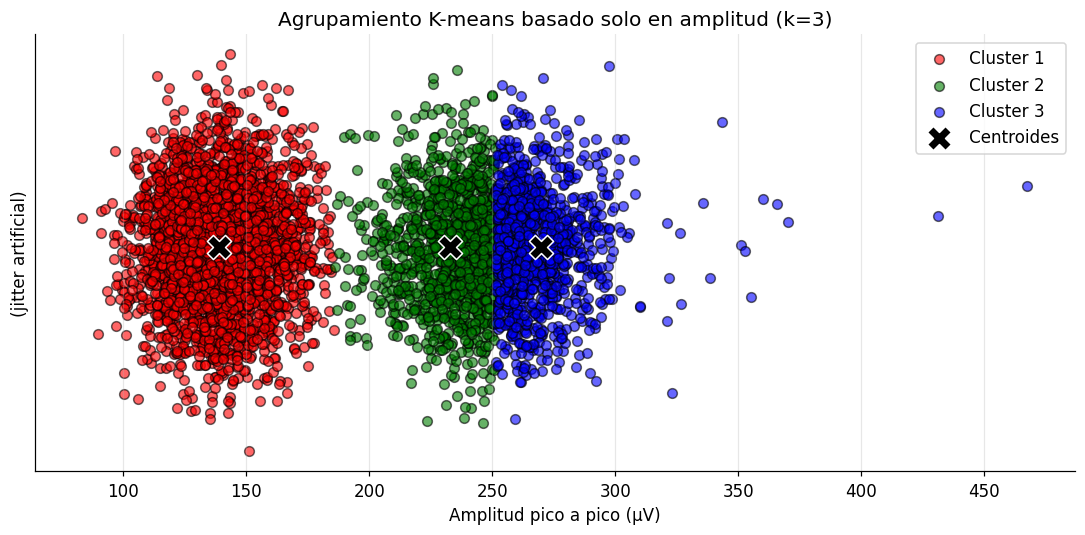

In [ ]:
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================================
# 1. Obtener amplitudes pico a pico (si no las tienes aún)
# ============================================================
pre_ms = 0.7
post_ms = 1.3
n_pre = int(round(pre_ms * fs / 1000.0))
n_post = int(round(post_ms * fs / 1000.0))

# Re-detectar spikes to get the full list of indices for this analysis context
# This ensures 'indices' refers to the full set of detected spikes for this amplitude-only clustering
indices_amplitude_only = detectar_spikes(AP, fs, k=4.5, muerto_ms=1.5)

amplitudes_pp = []
indices_validos = []   # positions of valid spikes within indices_amplitude_only

for j, idx in enumerate(indices_amplitude_only):
    inicio = idx - n_pre
    fin = idx + n_post
    if inicio < 0 or fin >= len(AP):
        continue
    ventana = AP[inicio:fin+1]
    amp = np.max(ventana) - np.min(ventana)
    amplitudes_pp.append(amp)
    indices_validos.append(j)

amplitudes = np.array(amplitudes_pp)
indices_validos = np.array(indices_validos)

# ============================================================
# 2. Preparar datos para K-means (una sola característica)
# ============================================================
X = amplitudes.reshape(-1, 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
etiquetas_clustering = kmeans.fit_predict(X_scaled)

# Create a padded labels array to match the original 'indices_amplitude_only'
# Fill with NaN for spikes that were discarded during feature extraction
etiquetas_amplitude_only_padded = np.full(len(indices_amplitude_only), np.nan)
etiquetas_amplitude_only_padded[indices_validos] = etiquetas_clustering

# ============================================================
# 3. Gráfico de dispersión 1D con jitter
# ============================================================
plt.figure(figsize=(10, 5))

# Ruido vertical para separar visualmente los puntos
rng = np.random.default_rng(42)
jitter = rng.normal(0, 0.08, size=len(amplitudes))

colores = ['red', 'green', 'blue']
for cluster in range(3):
    mascara = (etiquetas_clustering == cluster)
    plt.scatter(
        amplitudes[mascara],
        jitter[mascara],
        c=colores[cluster],
        alpha=0.6,
        edgecolors='k',
        s=40,
        label=f'Cluster {cluster+1}'
    )

# Marcar centroides en el eje X (con y=0)
centroides_original = scaler.inverse_transform(kmeans.cluster_centers_).flatten()
plt.scatter(
    centroides_original,
    np.zeros_like(centroides_original),
    c='black',
    marker='X',
    s=250,
    edgecolors='white',
    label='Centroides',
    zorder=5
)

# Ocultar eje Y (solo nos interesa la amplitud en X)
plt.yticks([])
plt.ylabel('(jitter artificial)')
plt.xlabel('Amplitud pico a pico (µV)')
plt.title('Agrupamiento K-means basado solo en amplitud (k=3)')
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Make these global so the verification cell can access them
global indices_amplitude_only_full, etiquetas_amplitude_only_for_verification
indices_amplitude_only_full = indices_amplitude_only
etiquetas_amplitude_only_for_verification = etiquetas_amplitude_only_padded

In [ ]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices_amplitude_only_full / fs, etiquetas_amplitude_only_for_verification)

  Spikes tuyos emparejados con uno real: 5454
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
         2.0       1002       15        1
         0.0          3     2646      596
         1.0       1154       35        2

  Acierto   69.7%  ████████████████████········

  ▸ La separación no funciona. ¿Sobre qué característica estás
    agrupando? ¿Basta con esa?


---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

Total de ISI globales: 5457
Fracción de ISI < 2 ms (global): 0.0073
Unidades encontradas: [0. 1. 2.]
Unidad 0: 2919 ISI, fracción < 2 ms = 0.0003
Unidad 1: 2185 ISI, fracción < 2 ms = 0.0009
Unidad 2: 344 ISI, fracción < 2 ms = 0.0000


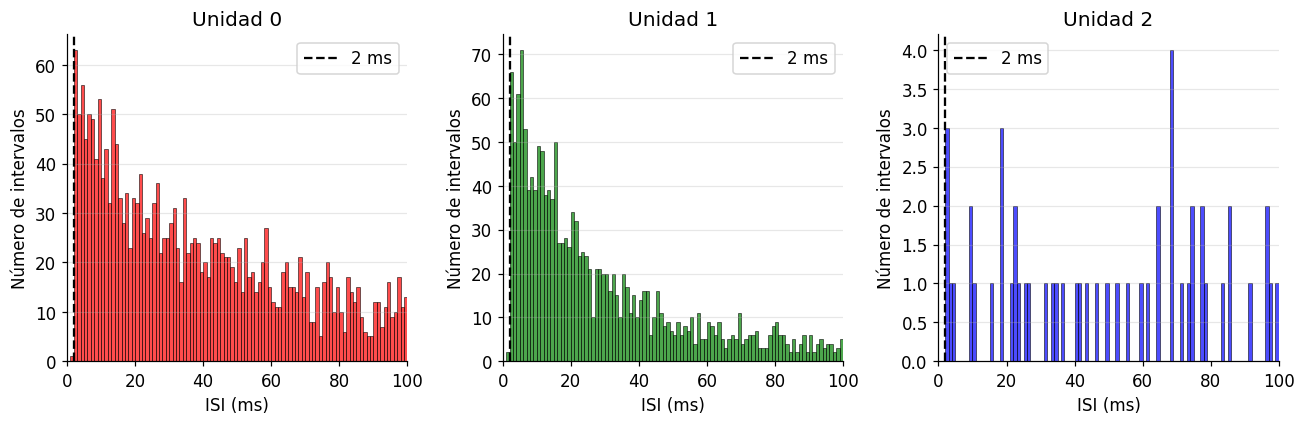

In [ ]:

# ============================================================
# 1. ISI global (todos los disparos juntos)
# ============================================================
# tiempos_s: array de tiempos de todos los spikes detectados (s)
# Asegurarse de que estén ordenados
tiempos_ordenados = np.sort(tiempos_s)

# Calcular diferencias entre disparos consecutivos (en segundos)
isi_global_s = np.diff(tiempos_ordenados)

# Convertir a milisegundos
isi_global_ms = isi_global_s * 1000.0

# Fracción de ISI menores a 2 ms
fraccion_menor_2ms = np.sum(isi_global_ms < 2.0) / len(isi_global_ms)

print(f"Total de ISI globales: {len(isi_global_ms)}")
print(f"Fracción de ISI < 2 ms (global): {fraccion_menor_2ms:.4f}")

# ============================================================
# 2. ISI por unidad (usando etiquetas del clustering)
# ============================================================
# etiquetas: array con la misma longitud que tiempos_s
#            valores 0,1,2 para unidades válidas, np.nan para no clasificados

# Obtener las unidades únicas (excluyendo NaN)
unidades = np.unique(etiquetas[~np.isnan(etiquetas)])
print(f"Unidades encontradas: {unidades}")

# Diccionario para guardar los ISI en ms de cada unidad
isi_por_unidad = {}

for unidad in unidades:
    # Tiempos de los spikes de esta unidad
    mascara = (etiquetas == unidad)
    tiempos_unidad = tiempos_s[mascara]
    tiempos_unidad = np.sort(tiempos_unidad)

    # Calcular ISI en ms
    isi_unidad_s = np.diff(tiempos_unidad)
    isi_unidad_ms = isi_unidad_s * 1000.0

    isi_por_unidad[unidad] = isi_unidad_ms

    # Fracción de ISI < 2 ms en esta unidad
    fraccion_unidad = np.sum(isi_unidad_ms < 2.0) / len(isi_unidad_ms)
    print(f"Unidad {int(unidad)}: {len(isi_unidad_ms)} ISI, "
          f"fracción < 2 ms = {fraccion_unidad:.4f}")

# ============================================================
# 3. Histogramas de ISI por unidad
# ============================================================
plt.figure(figsize=(12, 4))

# Colores para cada unidad
colores = ['red', 'green', 'blue']

for i, unidad in enumerate(unidades):
    plt.subplot(1, len(unidades), i+1)
    isi_ms = isi_por_unidad[unidad]

    # Histograma de 0 a 100 ms con bins de 1 ms
    bins = np.arange(0, 101, 1)  # [0,1), [1,2), ..., [99,100)
    plt.hist(isi_ms, bins=bins, color=colores[i], alpha=0.7,
             edgecolor='black', linewidth=0.5)

    # Línea vertical en 2 ms
    plt.axvline(x=2.0, color='black', linestyle='--', linewidth=1.5,
                label='2 ms')

    plt.xlabel('ISI (ms)')
    plt.ylabel('Número de intervalos')
    plt.title(f'Unidad {int(unidad)}')
    plt.xlim(0, 100)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Spikes detectados con muerto_ms=0.4: 5521
Spikes válidos para clustering: 5521

--- ISI Global ---
Total ISI: 5520
Fracción < 2 ms: 0.0192

--- ISI por Unidad ---
Unidad 0: 3277 ISI, fracción < 2 ms = 0.0027
Unidad 1: 1154 ISI, fracción < 2 ms = 0.0130
Unidad 2: 1087 ISI, fracción < 2 ms = 0.0110


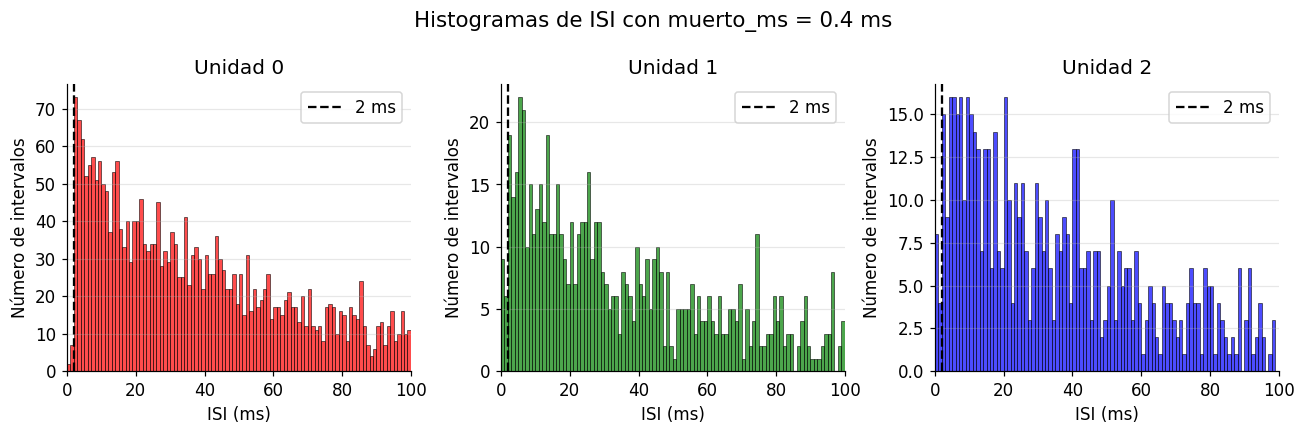

In [ ]:
#Con tiempo_muesto = 0,4 ms

# ============================================================
# Parámetros
# ============================================================
pre_ms = 0.7
post_ms = 1.3
n_pre = int(round(pre_ms * fs / 1000.0))
n_post = int(round(post_ms * fs / 1000.0))

muerto_ms_actual = 0.4   # <-- cambio aquí

# ============================================================
# 1. Detección de spikes con muerto_ms = 0.4
# ============================================================
indices = detectar_spikes(AP, fs, k=4.5, muerto_ms=muerto_ms_actual)
tiempos_s = indices / fs          # todos los tiempos

# ============================================================
# 2. Extracción de amplitudes pico a pico (solo válidas)
# ============================================================
amplitudes_pp = []
indices_validos = []   # posiciones originales en 'indices'

for j, idx in enumerate(indices):
    inicio = idx - n_pre
    fin = idx + n_post
    if inicio < 0 or fin >= len(AP):
        continue
    ventana = AP[inicio:fin+1]
    amp = np.max(ventana) - np.min(ventana)
    amplitudes_pp.append(amp)
    indices_validos.append(j)

amplitudes = np.array(amplitudes_pp)
indices_validos = np.array(indices_validos)

print(f"Spikes detectados con muerto_ms={muerto_ms_actual}: {len(tiempos_s)}")
print(f"Spikes válidos para clustering: {len(amplitudes)}")

# ============================================================
# 3. K-means (k=3) solo con amplitud pico a pico
# ============================================================
X = amplitudes.reshape(-1, 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
etiquetas_clustering = kmeans.fit_predict(X_scaled)

# ============================================================
# 4. Crear vector 'etiquetas' con misma longitud que tiempos_s
# ============================================================
etiquetas2 = np.full(len(tiempos_s), np.nan)
etiquetas2[indices_validos] = etiquetas_clustering

# ============================================================
# 5. Cálculo de ISI global
# ============================================================
tiempos_ordenados = np.sort(tiempos_s)
isi_global_s = np.diff(tiempos_ordenados)
isi_global_ms = isi_global_s * 1000.0

fraccion_global_menor_2ms = np.sum(isi_global_ms < 2.0) / len(isi_global_ms)

print("\n--- ISI Global ---")
print(f"Total ISI: {len(isi_global_ms)}")
print(f"Fracción < 2 ms: {fraccion_global_menor_2ms:.4f}")

# ============================================================
# 6. ISI por unidad
# ============================================================
unidades = np.unique(etiquetas2[~np.isnan(etiquetas2)])
isi_por_unidad = {}

print("\n--- ISI por Unidad ---")
for unidad in unidades:
    mascara = (etiquetas2 == unidad)
    tiempos_unidad = np.sort(tiempos_s[mascara])
    isi_unidad_s = np.diff(tiempos_unidad)
    isi_unidad_ms = isi_unidad_s * 1000.0
    isi_por_unidad[unidad] = isi_unidad_ms

    fraccion_unidad = np.sum(isi_unidad_ms < 2.0) / len(isi_unidad_ms)
    print(f"Unidad {int(unidad)}: {len(isi_unidad_ms)} ISI, "
          f"fracción < 2 ms = {fraccion_unidad:.4f}")

# ============================================================
# 7. Histogramas de ISI por unidad
# ============================================================
plt.figure(figsize=(12, 4))
colores = ['red', 'green', 'blue']

for i, unidad in enumerate(unidades):
    plt.subplot(1, len(unidades), i+1)
    isi_ms = isi_por_unidad[unidad]

    bins = np.arange(0, 101, 1)   # 0 a 100 ms en pasos de 1 ms
    plt.hist(isi_ms, bins=bins, color=colores[i % len(colores)],
             alpha=0.7, edgecolor='black', linewidth=0.5)

    plt.axvline(x=2.0, color='black', linestyle='--', linewidth=1.5,
                label='2 ms')
    plt.xlabel('ISI (ms)')
    plt.ylabel('Número de intervalos')
    plt.title(f'Unidad {int(unidad)}')
    plt.xlim(0, 100)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.suptitle(f'Histogramas de ISI con muerto_ms = {muerto_ms_actual} ms',
             fontsize=14)
plt.tight_layout()
plt.show()

**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | |
| unidad 1 | |
| unidad 2 | |
| unidad 3 | |

¿Alguna unidad está contaminada? ¿Cuál y por qué?

¿Qué pasó al bajar el período muerto a 0,4 ms?

**R/** Aunque el comportamiento de la unidad 2 se aleja mucho de los de las otras neuronas, no observamos contaminación. Al aumentar el tiempo muerto a 0,4 ms, la unidad 2 pasa a comportarse más como las otras unidades. Sin embargo, se contaminan las señales de todas las unidades porque hay un gran número de intervalos de menos de 2 ms, lo que indica que se mezclan señales.

---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [ ]:
# Abrir el archivo
with h5py.File(ARCHIVO, "r") as f:

    # Grupo que contiene la información de los estímulos
    estimulos = f["estimulos"]

    # Instante de inicio de cada ensayo (s)
    inicios = estimulos["tiempo_inicio_s"][:]

    # Condición de cada ensayo
    condiciones = estimulos["condicion"][:]

    # Decodificar de bytes a texto
    condiciones = np.array([
        c.decode("utf-8") if isinstance(c, bytes) else c
        for c in condiciones
    ])

    # Duración del pre-estímulo (s)
    t_pre = estimulos.attrs["duracion_pre_s"]

    # Duración del estímulo (s)
    t_est = estimulos.attrs["duracion_estimulo_s"]



inicios     = inicios     # instante de inicio de cada ENSAYO, en segundos
condiciones = condiciones     # la condición de cada ensayo ('A', 'B' o 'C')
t_pre       = t_pre     # cuánto dura el pre-estímulo dentro del ensayo, en segundos
t_est       = t_est     # cuánto dura el estímulo, en segundos

In [ ]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [ ]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """
    Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo.

    Parámetros
    ----------
    tiempos : array_like
        Tiempos de spikes (en segundos) globales, no necesariamente ordenados.
    inicios : array_like
        Tiempos de inicio de cada ensayo (en segundos).
    t_pre : float
        Duración del pre-estímulo (segundos). El estímulo comienza en
        inicio + t_pre.
    ventana : tuple, opcional
        Ventana relativa al estímulo (antes, después) en segundos.
        Solo se incluyen spikes dentro de [t_estimulo + antes, t_estimulo + después].

    Devuelve
    --------
    lista de np.ndarray
        Cada elemento es un arreglo 1D con los tiempos relativos al estímulo
        de los spikes que caen dentro de la ventana para ese ensayo.
    """
    # Asegurar que trabajamos con arrays numpy
    tiempos = np.asarray(tiempos, dtype=float).ravel()
    inicios = np.asarray(inicios, dtype=float).ravel()
    t_pre = float(t_pre)
    antes, despues = ventana

    # Ordenar los tiempos de spikes para búsqueda eficiente
    tiempos_ordenados = np.sort(tiempos)

    resultados = []

    for inicio in inicios:
        # Tiempo de referencia (inicio del estímulo)
        ref = inicio + t_pre

        # Límites de la ventana en tiempo global
        t_min = ref + antes
        t_max = ref + despues

        # Encontrar índices de spikes dentro de [t_min, t_max]
        idx_izq = np.searchsorted(tiempos_ordenados, t_min, side='left')
        idx_der = np.searchsorted(tiempos_ordenados, t_max, side='right')

        # Extraer los tiempos y hacerlos relativos al estímulo
        relativos = tiempos_ordenados[idx_izq:idx_der] - ref

        resultados.append(relativos)

    return resultados
# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [ ]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.
import numpy as np

# Supón que ya tienes definidas las variables:
# tiempos   : array de tiempos globales de spikes (s)
# inicios   : array de inicios de cada ensayo (s)
# t_pre     : duración del pre-estímulo (s)
# ventana   : tupla (antes, después) en segundos, por defecto (-1.0, 2.0)

# Seleccionar un ensayo arbitrario (por ejemplo, el primero)
ensayo_idx = 0

# Tiempo de inicio del estímulo para ese ensayo
ref = inicios[ensayo_idx] + t_pre

# Definir la ventana (usa la misma que en alinear)
antes, despues = (-1.0, 2.0)   # ajusta si usas otra
t_min = ref + antes
t_max = ref + despues

# Extraer los spikes absolutos que caen dentro de la ventana
mascara = (tiempos >= t_min) & (tiempos <= t_max)
spikes_absolutos = tiempos[mascara]

# Convertir a relativos al estímulo
spikes_relativos_manual = spikes_absolutos - ref

# Llamar a la función alinear y obtener el resultado para ese ensayo
# (si alinear devuelve una lista, tomamos el elemento ensayo_idx)
resultados_alinear = alinear(tiempos, inicios, t_pre, ventana=(antes, despues))
spikes_relativos_funcion = resultados_alinear[ensayo_idx]

# Comparar
print(f"Ensayo {ensayo_idx}:")
print(f"  Inicio del estímulo: {ref:.3f} s")
print(f"  Spikes absolutos en ventana: {spikes_absolutos}")
print(f"  Relativos calculados manualmente: {spikes_relativos_manual}")
print(f"  Relativos devueltos por alinear:  {spikes_relativos_funcion}")

if np.array_equal(spikes_relativos_manual, spikes_relativos_funcion):
    print("✔ Coinciden exactamente.")
else:
    print("✘ No coinciden. Revisa la implementación.")

Ensayo 0:
  Inicio del estímulo: 31.000 s
  Spikes absolutos en ventana: [30.0005  30.0627  30.06985 30.1048  30.127   30.14475 30.1718  30.2017
 30.207   30.39005 30.39705 30.52335 30.57705 30.58875 30.59365 30.66875
 30.76445 30.8206  30.82375 30.8384  30.93455 31.0018  31.02705 31.0364
 31.07235 31.10715 31.1228  31.1259  31.15265 31.15485 31.1643  31.16655
 31.17895 31.192   31.2322  31.23945 31.2438  31.2477  31.2634  31.2764
 31.2911  31.30085 31.30415 31.31115 31.31595 31.31975 31.3264  31.33
 31.34115 31.35205 31.3553  31.35865 31.36405 31.3702  31.38085 31.409
 31.41465 31.41935 31.436   31.44035 31.48305 31.4928  31.49935 31.5887
 31.638   31.65865 31.66655 31.7601  31.77895 31.82705 31.8731  31.98475
 32.09795 32.1283  32.2013  32.2465  32.256   32.28715 32.4114  32.42205
 32.4534  32.4592  32.50665 32.57815 32.58965 32.63355 32.7104  32.81865
 32.88865 32.89675 32.9652  32.9748 ]
  Relativos calculados manualmente: [-9.99500e-01 -9.37300e-01 -9.30150e-01 -8.95200e-01 -8.730

In [ ]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

Condiciones: ['A' 'B' 'C']


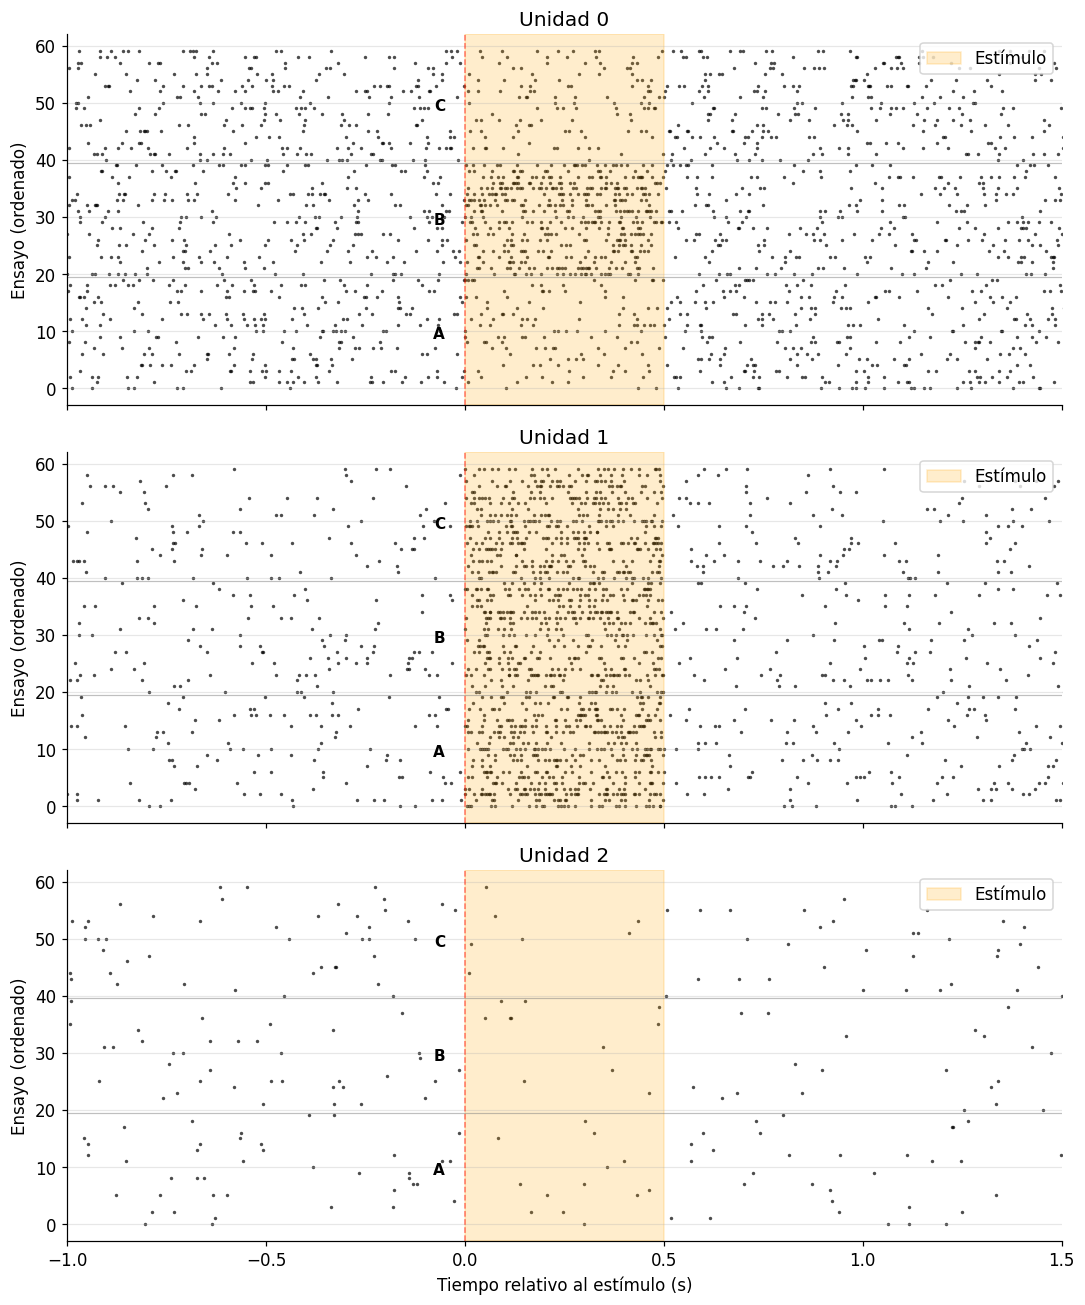

In [ ]:
# Su código aquí.

# ============================================================
# 0. Verificar que existen las variables necesarias
# ============================================================
# tiempos, etiquetas, inicios, t_pre, t_est, condiciones, alineados

# ============================================================
# 1. Preparar orden de ensayos por condición
# ============================================================
condiciones = np.asarray(condiciones)
condiciones_unicas = np.unique(condiciones)
print("Condiciones:", condiciones_unicas)

# Construir lista ordenada de índices de ensayo por condición
orden_ensayos = []
limites_cond = []   # guardará (inicio, fin, cond) para cada bloque

for cond in condiciones_unicas:
    indices = np.where(condiciones == cond)[0]
    inicio_bloque = len(orden_ensayos)
    orden_ensayos.extend(indices)
    fin_bloque = len(orden_ensayos) - 1
    limites_cond.append((inicio_bloque, fin_bloque, cond))

# ============================================================
# 2. Crear figura
# ============================================================
unidades = np.unique(etiquetas[~np.isnan(etiquetas)]) # Filtrar NaN de unidades
n_unidades = len(unidades)

fig, ejes = plt.subplots(n_unidades, 1, figsize=(10, 4*n_unidades), sharex=True)

# Asegurar que ejes sea iterable aunque haya una sola unidad
if n_unidades == 1:
    ejes = [ejes]

# ============================================================
# 3. Dibujar cada unidad
# ============================================================
for ax, unidad in zip(ejes, unidades):
    # Obtener los spikes alineados de esta unidad
    lista_ensayos = alineados[unidad]   # lista de arreglos, uno por ensayo original

    # Dibujar los spikes en el orden de ensayos por condición
    for y_pos, idx_original in enumerate(orden_ensayos):
        spikes_rel = lista_ensayos[idx_original]
        if len(spikes_rel) > 0:
            ax.scatter(spikes_rel, np.full_like(spikes_rel, y_pos),
                       color='black', s=5, alpha=0.7, linewidths=0)

    # Sombrear la ventana del estímulo
    ax.axvspan(0, t_est, color='orange', alpha=0.2, label='Estímulo')

    # Línea vertical en t=0 (inicio del estímulo)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)

    # Añadir líneas horizontales separando condiciones
    for inicio, fin, cond in limites_cond:
        # Línea al final del bloque (excepto si es el último bloque)
        if fin < len(orden_ensayos) - 1:
            ax.axhline(fin + 0.5, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
        # Etiqueta de condición en el centro del bloque
        centro = (inicio + fin) / 2
        ax.text(-0.05, centro, f'{cond}', ha='right', va='center',
                fontsize=10, fontweight='bold')

    # Configurar ejes
    ax.set_ylabel('Ensayo (ordenado)')
    ax.set_title(f'Unidad {int(unidad)}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlim(-1.0, t_est + 1.0)   # ventana de visualización
    ax.legend(loc='upper right')

# Etiqueta común para el eje X
ejes[-1].set_xlabel('Tiempo relativo al estímulo (s)')

plt.tight_layout()
plt.show()

**Lo que leemos en el raster:** Vemos que la Unidad 0 responde en la condición B, la Unidad 1 responde a todas las condiciones y la Unidad 2 no responde a ninguna condición.

---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?
**R/** Elegiría el bin de 20ms porque no genera tanto ruido como la de 5ms, pero no me elimina tanta información como la de 200 ms, y conserva más valles y picos que la de 50 ms.

In [ ]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """
    Calcula el histograma de tiempo periestímulo (PSTH) promedio.

    Parámetros
    ----------
    ensayos_alineados : list of np.ndarray
        Lista donde cada elemento es un arreglo 1D con los tiempos de spikes
        relativos al estímulo (en segundos) para un ensayo.
    ventana : tuple (inicio, fin)
        Límites temporales (en segundos) relativos al estímulo para el histograma.
    ancho_bin_s : float
        Ancho de cada bin en segundos.

    Devuelve
    --------
    centros_bin : np.ndarray
        Centros de los bins (en segundos).
    tasa_Hz : np.ndarray
        Tasa de disparo promedio en disparos por segundo (Hz) para cada bin.
    """
    inicio, fin = ventana
    n_bins = int(np.ceil((fin - inicio) / ancho_bin_s))
    bordes = inicio + np.arange(n_bins + 1) * ancho_bin_s   # bordes de bins en s
    centros = (bordes[:-1] + bordes[1:]) / 2.0              # centros en s

    # Contar spikes en cada bin sumando todos los ensayos
    conteo_total = np.zeros(n_bins)
    for spikes in ensayos_alineados:
        if len(spikes) > 0:
            hist, _ = np.histogram(spikes, bins=bordes)
            conteo_total += hist

    # Convertir a tasa: dividir por número de ensayos y por ancho de bin
    n_ensayos = len(ensayos_alineados)
    if n_ensayos == 0:
        raise ValueError("No hay ensayos para calcular el PSTH")
    tasa = conteo_total / (n_ensayos * ancho_bin_s)   # spikes/s = Hz

    return centros, tasa


In [ ]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


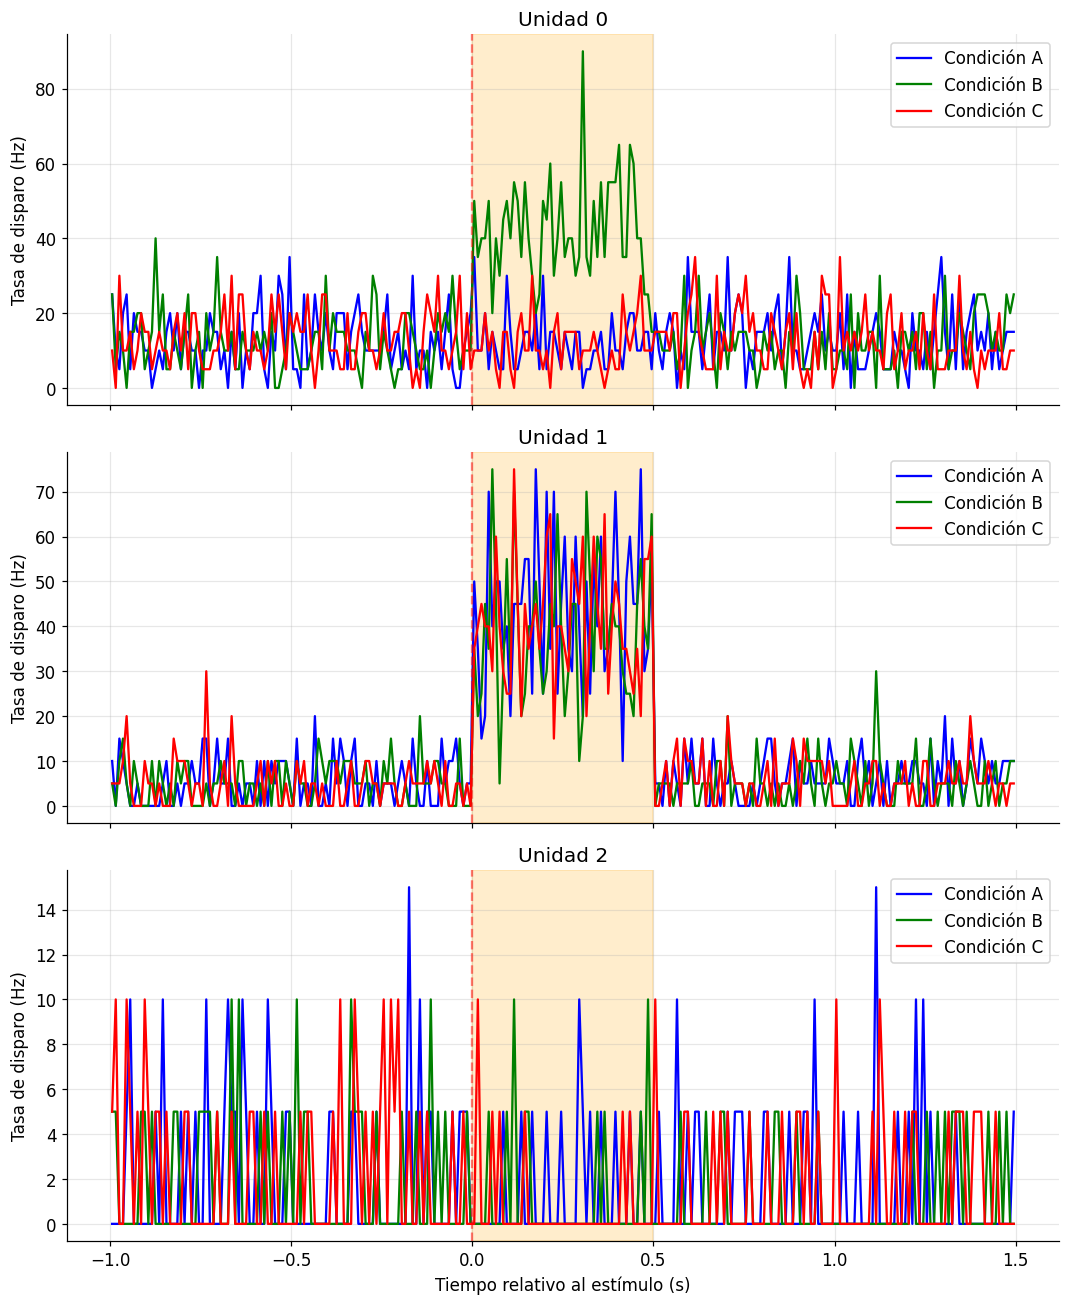

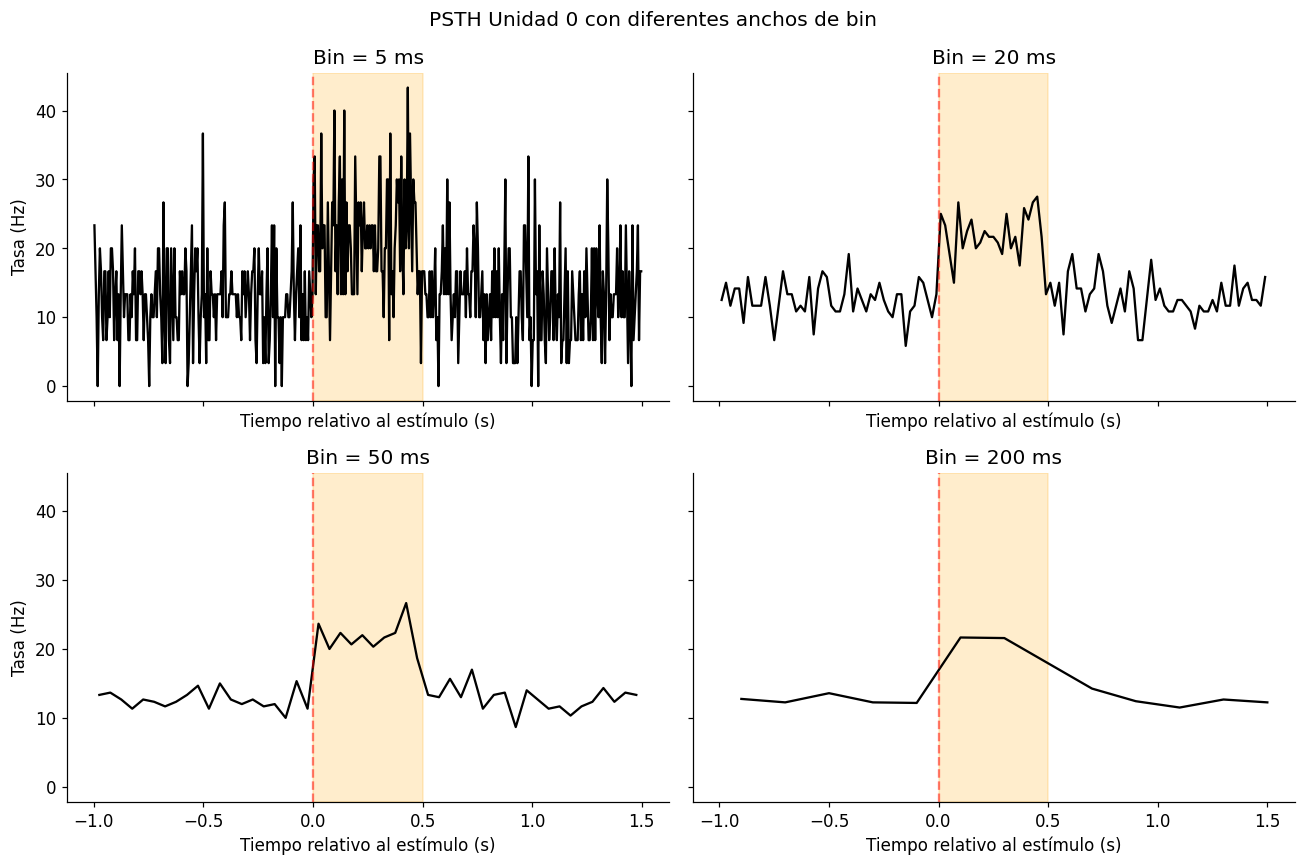

In [ ]:
# Ejercicios M2 y M3: su código aquí.

# ============================================================
# Gráfica de PSTH por unidad y condición
# ============================================================
# Variables necesarias:
# unidades, condiciones, alineados, t_est (duración del estímulo)

# Definir ventana de visualización (por ejemplo, desde -1 s hasta t_est+1 s)
ventana_psth = (-1.0, t_est + 1.0)
ancho_bin = 0.01   # 10 ms

condiciones_unicas = np.unique(condiciones)
colores_cond = {'A': 'blue', 'B': 'green', 'C': 'red'}   # ajusta si hay más

# Crear figura con subplots: una fila por unidad
fig, ejes = plt.subplots(len(unidades), 1, figsize=(10, 4*len(unidades)), sharex=True)
if len(unidades) == 1:
    ejes = [ejes]

for ax, unidad in zip(ejes, unidades):
    # Obtener los ensayos alineados de esta unidad
    ensayos_por_unidad = alineados[unidad]   # lista de arreglos por ensayo

    for cond in condiciones_unicas:
        # Índices de ensayos que pertenecen a esta condición
        idx_cond = np.where(condiciones == cond)[0]

        # Extraer solo los ensayos de esta condición
        ensayos_cond = [ensayos_por_unidad[i] for i in idx_cond]

        # Calcular PSTH
        centros, tasa = psth(ensayos_cond, ventana_psth, ancho_bin)

        # Graficar
        ax.plot(centros, tasa, color=colores_cond.get(cond, 'black'),
                label=f'Condición {cond}')

    # Sombrear estímulo
    ax.axvspan(0, t_est, color='orange', alpha=0.2)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

    ax.set_ylabel('Tasa de disparo (Hz)')
    ax.set_title(f'Unidad {int(unidad)}')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

# Último eje lleva etiqueta de tiempo
ejes[-1].set_xlabel('Tiempo relativo al estímulo (s)')
plt.tight_layout()
plt.show()

# Suponiendo que ya están definidas:
# alineados, unidades, t_est, psth

unidad = 0  # puede ser 0,1,2 según etiquetas
ventana = (-1.0, t_est + 1.0)

anchos_bin_s = [0.005, 0.02, 0.05, 0.2]  # 5, 20, 50, 200 ms
fig, ejes_bins = plt.subplots(2, 2, figsize=(12, 8), sharey=True, sharex=True)

# Obtener todos los ensayos de la unidad 0 (todas las condiciones)
ensayos_unidad = alineados[unidad]   # lista de arreglos

# Iterar sobre las filas y columnas del arreglo de ejes para los diferentes bins
for r_idx in range(ejes_bins.shape[0]):
    for c_idx in range(ejes_bins.shape[1]):
        ax = ejes_bins[r_idx, c_idx]
        # Obtener el ancho de bin correspondiente de la lista aplanada
        ancho = anchos_bin_s[r_idx * ejes_bins.shape[1] + c_idx]

        centros, tasa = psth(ensayos_unidad, ventana, ancho)
        ax.plot(centros, tasa, color='black')
        ax.axvspan(0, t_est, color='orange', alpha=0.2)
        ax.axvline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_title(f'Bin = {ancho*1000:.0f} ms')
        ax.set_xlabel('Tiempo relativo al estímulo (s)')
        if c_idx == 0: # Solo establecer el ylabel para la primera columna
            ax.set_ylabel('Tasa (Hz)')

plt.suptitle(f'PSTH Unidad {int(unidad)} con diferentes anchos de bin')
plt.tight_layout()
plt.show()

**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

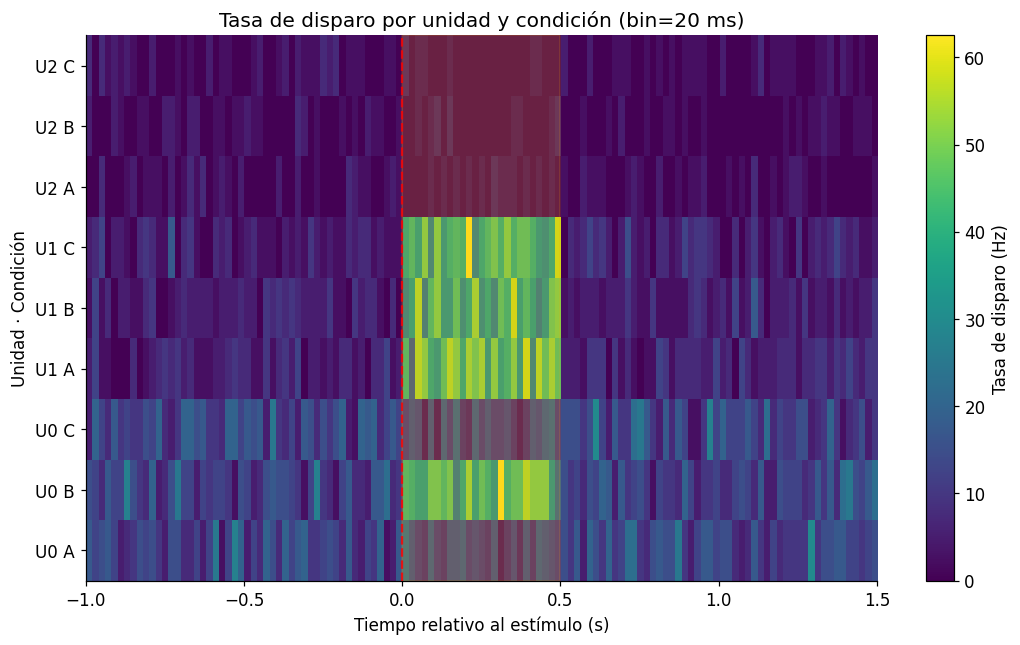

In [ ]:
# Su código aquí.
import matplotlib.colors as mcolors

# ============================================================
# Parámetros
# ============================================================
ancho_bin_s = 0.02  # 20 ms
ventana = (-1.0, t_est + 1.0)   # desde 1 s antes hasta 1 s después del fin del estímulo
inicio, fin = ventana
n_bins = int(np.ceil((fin - inicio) / ancho_bin_s))
bordes = inicio + np.arange(n_bins + 1) * ancho_bin_s
centros = (bordes[:-1] + bordes[1:]) / 2.0

# Obtener unidades y condiciones únicas
unidades = np.unique(etiquetas[~np.isnan(etiquetas)])  # Filtrar NaN de unidades
condiciones_unicas = np.unique(condiciones)

# ============================================================
# Construir matriz de tasas (n_filas = n_unidades * n_condiciones)
# ============================================================
n_filas = len(unidades) * len(condiciones_unicas)
matriz_tasas = np.zeros((n_filas, n_bins))
etiquetas_filas = []   # para anotar qué fila corresponde a qué unidad/condición

fila_idx = 0
for unidad in unidades:
    for cond in condiciones_unicas:
        # Filtrar ensayos de esta unidad y condición
        idx_cond = np.where(condiciones == cond)[0]
        # Obtener ensayos alineados para esta unidad (lista de arreglos)
        ensayos_unidad = alineados[unidad]
        ensayos_filtrados = [ensayos_unidad[i] for i in idx_cond]

        # Calcular PSTH con la función definida
        _, tasa = psth(ensayos_filtrados, ventana, ancho_bin_s)

        # Guardar en matriz
        matriz_tasas[fila_idx, :] = tasa
        etiquetas_filas.append(f"U{int(unidad)} {cond}")
        fila_idx += 1

# ============================================================
# Graficar heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

# Usar un colormap perceptualmente uniforme (evita 'jet')
cmap = plt.get_cmap('viridis')

# Mostrar matriz con imshow
im = ax.imshow(matriz_tasas,
               aspect='auto',
               origin='lower',
               cmap=cmap,
               interpolation='nearest',
               extent=[inicio, fin, -0.5, n_filas - 0.5])

# Línea vertical en t=0
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8);

# Marcar la ventana del estímulo (sombreado)
ax.axvspan(0, t_est, color='orange', alpha=0.2);

# Configurar ejes
ax.set_yticks(np.arange(n_filas))
ax.set_yticklabels(etiquetas_filas)
ax.set_xlabel('Tiempo relativo al estímulo (s)')
ax.set_ylabel('Unidad · Condición')
ax.set_title('Tasa de disparo por unidad y condición (bin=20 ms)')

# Añadir barra de color compartida
cbar = fig.colorbar(im, ax=ax, label='Tasa de disparo (Hz)')

# Ajustar límites de color para compartir escala (opcional: usar vmin/vmax globales)
# En este caso, como todas las filas usan la misma escala, el colorbar es global automáticamente.

plt.tight_layout()
plt.show()

**Lo que el heatmap muestra y el PSTH escondía:** La señal de la Unidad 0 es más fuerte que la de las otras unidades fuera de la ventanta del estímulo. Sin embargo, las observaciones previas se mantienen: la U0 responde a condicion B, la U1 responde a todas las condiciones y la U2 responde de una manera inespecífica y poco fuerte.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

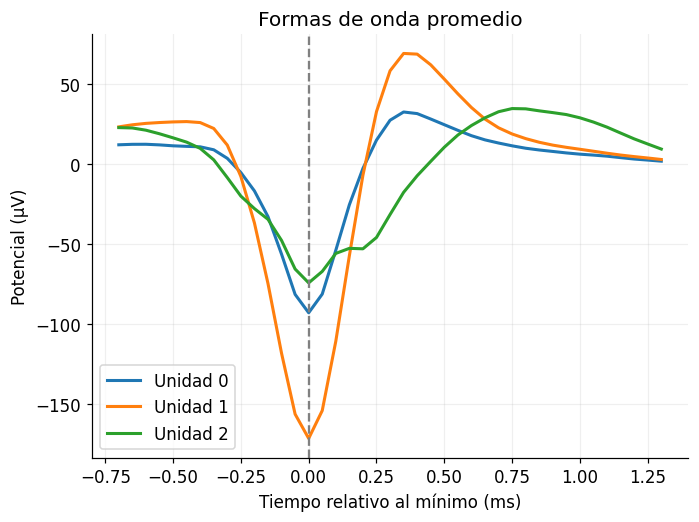

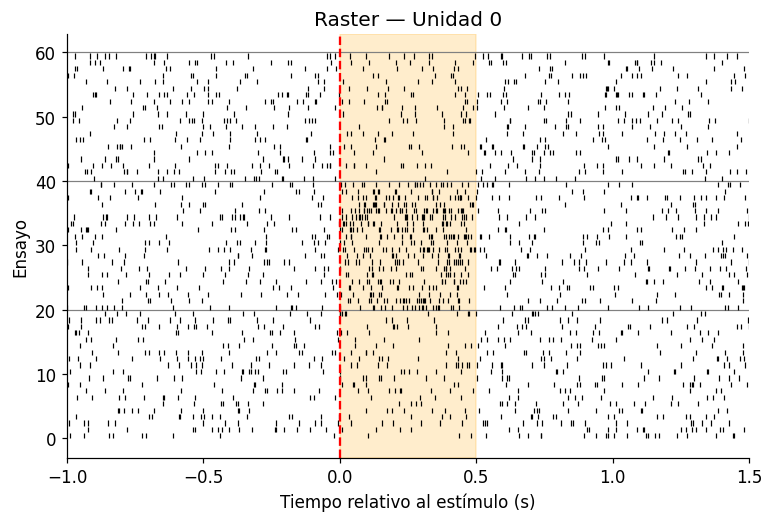

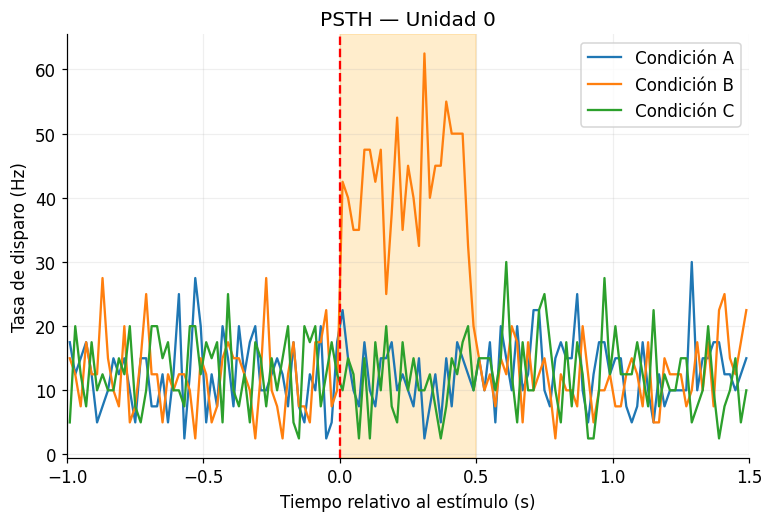

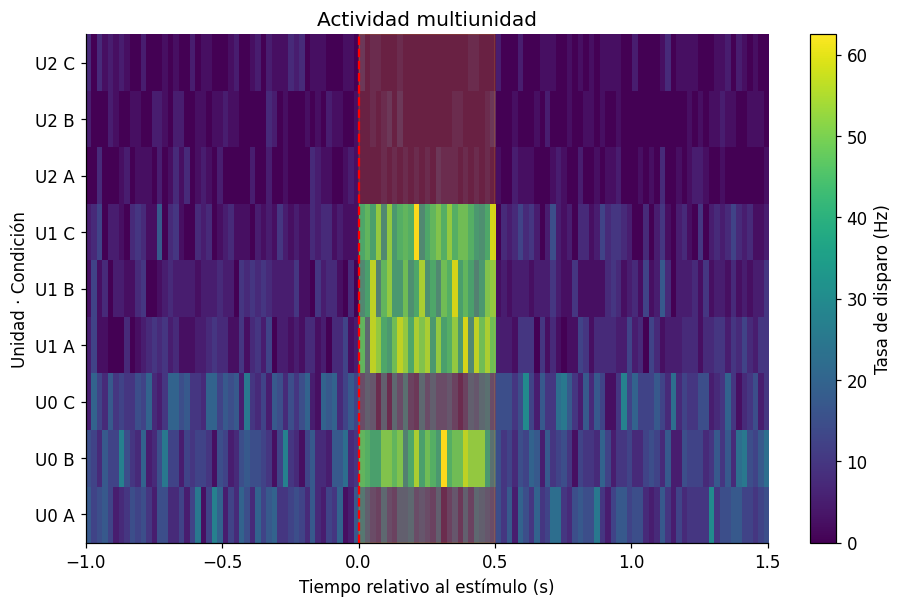

In [ ]:
# PANEL A — Formas de onda promedio de las 3 unidades

import numpy as np
import matplotlib.pyplot as plt

# Eje temporal de cada forma de onda, en milisegundos
t_formas = (np.arange(formas.shape[1]) - n_pre) / fs * 1000

# Crear figura
plt.figure(figsize=(7, 5))

# Graficar el promedio de cada unidad
for unidad in [0, 1, 2]:

    # Seleccionar los spikes que pertenecen a esta unidad
    mascara = etiquetas == unidad

    # Promedio de todas sus formas de onda
    forma_promedio = formas[mascara].mean(axis=0)

    # Graficar
    plt.plot(
        t_formas,
        forma_promedio,
        linewidth=2,
        label=f"Unidad {unidad}"
    )

# Línea vertical en el mínimo del spike
plt.axvline(0, linestyle="--", color="gray")

plt.xlabel("Tiempo relativo al mínimo (ms)")
plt.ylabel("Potencial (µV)")
plt.title("Formas de onda promedio")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# PANEL B — Raster de la unidad que responde

unidad = 0
ensayos_unidad = alineados[unidad]

plt.figure(figsize=(8, 5))

fila = 0

for condicion in np.unique(condiciones):

    # Índices de los ensayos que pertenecen a esta condición
    indices_cond = np.where(condiciones == condicion)[0]

    for i in indices_cond:

        # Tiempos de spikes de ese ensayo
        spikes = ensayos_unidad[i]

        # Dibujar cada spike como una rayita vertical
        plt.vlines(
            spikes,
            fila,
            fila + 0.8,
            color="black",
            linewidth=0.8
        )

        fila += 1

    # Línea que separa una condición de la siguiente
    plt.axhline(fila, color="gray", linewidth=0.8)


# Marcar el estímulo
plt.axvline(0, color="red", linestyle="--")
plt.axvspan(0, t_est, color="orange", alpha=0.2)

plt.xlim(-1, t_est + 1)

plt.xlabel("Tiempo relativo al estímulo (s)")
plt.ylabel("Ensayo")
plt.title("Raster — Unidad 0")

plt.show()

# PANEL C — PSTH de la Unidad 0

unidad = 0
ensayos_unidad = alineados[unidad]

ventana = (-1.0, t_est + 1.0)
ancho_bin = 0.02   # 20 ms

plt.figure(figsize=(8, 5))

for condicion in np.unique(condiciones):

    # Buscar qué ensayos pertenecen a esta condición
    indices_cond = np.where(condiciones == condicion)[0]

    # Tomar solamente esos ensayos
    ensayos_cond = [ensayos_unidad[i] for i in indices_cond]

    # Calcular el PSTH
    centros, tasa = psth(
        ensayos_cond,
        ventana,
        ancho_bin
    )

    # Graficar
    plt.plot(
        centros,
        tasa,
        label=f"Condición {condicion}"
    )


# Marcar el estímulo
plt.axvline(0, color="red", linestyle="--")
plt.axvspan(0, t_est, color="orange", alpha=0.2)

plt.xlim(ventana)

plt.xlabel("Tiempo relativo al estímulo (s)")
plt.ylabel("Tasa de disparo (Hz)")
plt.title("PSTH — Unidad 0")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


# PANEL D — Heatmap multiunidad

ancho_bin_s = 0.02
ventana = (-1.0, t_est + 1.0)

inicio, fin = ventana

unidades = np.unique(etiquetas[~np.isnan(etiquetas)])
condiciones_unicas = np.unique(condiciones)

# Aquí guardaremos un PSTH por cada combinación unidad-condición
matriz_tasas = []
etiquetas_filas = []

for unidad in unidades:

    ensayos_unidad = alineados[unidad]

    for condicion in condiciones_unicas:

        # Ensayos que pertenecen a esa condición
        indices_cond = np.where(condiciones == condicion)[0]

        ensayos_cond = [
            ensayos_unidad[i]
            for i in indices_cond
        ]

        # Calcular PSTH
        centros, tasa = psth(
            ensayos_cond,
            ventana,
            ancho_bin_s
        )

        matriz_tasas.append(tasa)
        etiquetas_filas.append(
            f"U{int(unidad)} {condicion}"
        )

# Convertir la lista a matriz
matriz_tasas = np.array(matriz_tasas)


# -------------------------
# Graficar heatmap
# -------------------------

plt.figure(figsize=(10, 6))

plt.imshow(
    matriz_tasas,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    extent=[
        inicio,
        fin,
        -0.5,
        len(etiquetas_filas) - 0.5
    ]
)

# Etiquetas de cada fila
plt.yticks(
    np.arange(len(etiquetas_filas)),
    etiquetas_filas
)

# Marcar el estímulo
plt.axvline(0, color="red", linestyle="--")
plt.axvspan(0, t_est, color="orange", alpha=0.2)

# Barra de color
plt.colorbar(label="Tasa de disparo (Hz)")

plt.xlabel("Tiempo relativo al estímulo (s)")
plt.ylabel("Unidad · Condición")
plt.title("Actividad multiunidad")

plt.show()

**Pregunta P2.** El pie de la figura:

> Figura 1. Actividad neuronal y respuesta al estímulo de las unidades separadas. (A) Formas de onda promedio de las unidades 0, 1 y 2, alineadas al mínimo del potencial de acción. (B) Raster de la unidad 0 con los ensayos agrupados por condición. (C) PSTH de la unidad 0 para las condiciones A, B y C, calculado con bins de 20 ms. (D) Heatmap de la tasa de disparo de las tres unidades para cada condición. En los paneles temporales, la línea roja discontinua indica el inicio del estímulo y la región sombreada su duración (0–0,5 s).

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**


Heatmap multiunidad: la U0 responde selectivamente a la condición B, porque durante el estímulo (0–0,5 s) esa fila se vuelve mucho más intensa. La U1 responde fuertemente en A, B y C, así que parece sensible al estímulo pero no a una condición específica. La U2 tiene una actividad mucho menor y su respuesta al estímulo es débil.
PSTH de U0: confirma la selectividad. Antes del estímulo, las tres condiciones rondan aproximadamente 10–20 Hz. Durante B, la tasa sube a aproximadamente 35–60 Hz, mientras que A y C permanecen cerca de su actividad basal. Es la evidencia más clara de que U0 prefiere B.
Raster de U0: muestra lo mismo pero ensayo por ensayo, sin promediar. En el bloque correspondiente a B se ve una concentración mucho mayor de spikes dentro de la zona sombreada del estímulo. Eso indica que la respuesta a B es repetible entre ensayos, no solo un efecto del promedio.
Formas de onda promedio: las tres unidades tienen formas diferentes: U1 tiene el pico negativo de mayor amplitud, U0 uno intermedio y U2 una forma más distinta. Esto apoya que el spike sorting separó tres unidades neuronales diferentes.

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:** Para la gráfica del punto C1, de espectro de potencia escribimos este promt:
Chat, en lenguaje de python necesito definir una funcion espectro (), con la que necesito buscar un pico angosto en una frecuencia exacta: algo instrumental como la red eléctrica, energía en las frecuencias muy bajas (< 5 Hz): la deriva lenta, energía entre 300 y 3000 Hz: los potenciales de acción, un piso plano que nunca baja: ruido térmico, presente en todas las frecuencias. El tipo de datos tiene como entradas un array de voltaje, un titulo, un frecuencia maxima mostrada = 500 y una frecuencia de muestreo fs. Además la salida incluye dos arrays: Uno para las frecuencias en Hz y otro para la potencia en cada frecuencia. Utiliza scipy.signal.welch y nperseg=8192; graficar solo hasta fmax, con el eje y en escala logarítmica (plt.semilogy), ejes rotulados con unidades.

Después de obtener la gráfica, teniamos dudas al respecto así que le dimos la imagen junto con el siguiente promt:

Esta fue la imagen resultado que obtuvimos a partir del código. Explicanos que está mostrando la gráfica y si esto tiene sentido.


**Respuesta del modelo:**

En tu espectro se distinguen:

Energía muy alta en frecuencias bajas (especialmente < 5 Hz): corresponde a la deriva lenta de la señal.
Un pico muy angosto alrededor de 60 Hz: corresponde muy probablemente a interferencia de la red eléctrica.
Otro pico cerca de 120 Hz: es el segundo armónico de 60 Hz.
A partir de aproximadamente 150 Hz se ve un nivel relativamente plano alrededor de \(10^{-1}\,\mu V^2/Hz\): ese sería el piso de ruido presente en muchas frecuencias.

Además, tus ejes están bien:

X: Frecuencia (Hz)
Y: Densidad espectral de potencia (µV²/Hz)
Y está en escala logarítmica, como pedían.

Solo cambiaría el título "titulo" por algo descriptivo, por ejemplo:

f, potencia = espectro(
    cruda,
    "Espectro de potencia de la señal cruda",
    fs,
    fmax=500
)

**Qué estaba mal:**

En este caso, la IA no estaba mal pero nos ayudó a mejorar la gráfica poniendole titulo.

**Cómo lo corregimos:**

Agregamos el título correspondiente.

---

### Intercambio 2

**Prompt:**
Trabajo en Python con numpy y scipy. Tengo un array cruda con el voltaje (en µV) de un registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en 60 Hz y su armónico en 120 Hz. Escríbeme una función notch(x, f0, fs, Q=30) que use scipy.signal.iirnotch para diseñar el filtro y scipy.signal.filtfilt para aplicarlo. Explícame qué controla el parámetro Q y por qué en electrofisiología se usa filtfilt y no lfilter. Rotula todo con unidades y explícame cada línea.

**Respuesta del modelo:**

cruda_60 = notch(cruda, f0=60, fs=20000, Q=30)
cruda_limpia = notch(cruda_60, f0=120, fs=20000, Q=30)

sin_red = cruda_limpia

LFP = filtrar(cruda, fs, baja=300)

plt.figure()
ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)

plt.figure()
ver(LFP, "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)


**Qué estaba mal:**

El problema es que se estaba llamando al argumento equivocado para la función filtrar. Se usó baja=300, y en la función filtrar ese argumento indica un filtro pasa-altos. Sin embargo, la banda LFP corresponde a frecuencias menores de 300 Hz, por lo que debía usarse alta=300. Además, el filtrado debía aplicarse sobre sin_red, que ya tenía eliminados los componentes de 60 y 120 Hz.


**Cómo lo corregimos:**

Corregimos el fragmento de la siguiente manera:

cruda_60 = notch(cruda, f0=60, fs=fs, Q=30)
sin_red = notch(cruda_60, f0=120, fs=fs, Q=30)

LFP = filtrar(sin_red, fs, alta=300)

---

### Intercambio 3

**Prompt:**

Estoy trabajando con datos de spikes neuronales en Google Colab utilizando Python. Ya están definidas las variables: t: Tiempo del estímulo (Array de numeros igualmente espaciados), senal: Señal que está recibiendo el electrodo (Array), tiempos_A_det(Array), tiempos_B_det(Array), amplitudes(Array), es_A(Array), es_B(Array). Necesito que generes una figura que demuestre que la separación funcionó. los primeros 0.5 s de la señal, en gris, con un marcador triangular sobre el pico de cada spike — naranja para la neurona A, azul para la neurona B — y una leyenda



**Respuesta del modelo:**


import numpy as np
import matplotlib.pyplot as plt

mask = t <= 0.5

plt.figure(figsize=(12, 4))

plt.plot(t[mask], senal[mask], color='gray', linewidth=1)


plt.plot(tiempos_A_det,
         amplitudes[es_A],
         '^',
         color='orange',
         label='Neurona A')


plt.plot(tiempos_B_det,
         amplitudes[es_B],
         '^',
         color='blue',
         label='Neurona B')

plt.xlabel('Tiempo (s)')
plt.ylabel('Voltaje (µV)')
plt.title('Separación de spikes')
plt.xlim(0, 0.5)
plt.legend()

plt.show()

**Qué estaba mal:**

El problema es que el código limita a los primeros 0.5 s únicamente la señal gris usando mask, pero no hace esa misma selección para tiempos_A_det, tiempos_B_det ni para sus amplitudes correspondientes. Además, al usar directamente amplitudes[es_A] y amplitudes[es_B], se asume que esas amplitudes están perfectamente alineadas con tiempos_A_det y tiempos_B_det.

**Cómo lo corregimos:**

Se corrigió el codigo de la siguiente manera:

mask_A = tiempos_A_det <= 0.5

plt.plot(tiempos_A_det[mask_A],
         amplitudes[es_A][mask_A],
         '^',
         color='orange',
         label='Neurona A')


mask_B = tiempos_B_det <= 0.5

plt.plot(tiempos_B_det[mask_B],
         amplitudes[es_B][mask_B],
         '^',
         color='blue',
         label='Neurona B')

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [ ]:
tabla = pd.DataFrame({
    "tiempo_s": tiempos,
    "unidad": np.asarray(etiquetas)
})

tabla.to_csv("spikes_taller1.csv", index=False)

print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())

tabla.head()

# Indices fue sobrescrito después; usamos tiempos porque corresponde
# a la misma detección con la que se obtuvieron las etiquetas.

5458 disparos guardados en spikes_taller1.csv
unidad
0.0    2920
1.0    2186
2.0     345
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,1.0
1,0.15945,0.0
2,0.17240,0.0
3,0.28330,1.0
4,0.30670,0.0
